# Gene Expression Analysis - Complete Updated Colab Notebook
**Dataset:** GSE21050-style demo | **Platform:** GPL570-style | **Context:** Breast Cancer + Sarcoma subtype comparison

This updated notebook keeps the original workflow and integrates your guide's requested extension.

| Part | What it does |
|---|---|
| **Part A - Inline Analysis** | Original data loading, PCA, DEG table, volcano plot, heatmap, TP53 analysis, CSV export |
| **Part A9 - Sarcoma Insights** | Original sarcoma DEG summary retained |
| **Part A10 - New Sarcoma Subtype Comparative Analysis** | Compares 4 sarcoma subtypes: Osteosarcoma, Leiomyosarcoma, Liposarcoma and Rhabdomyosarcoma using one-vs-rest and pairwise differential expression |
| **Part B - Streamlit Dashboard** | Updated dashboard with old results + new subtype comparison, heatmaps, PCA, marker genes, pairwise results and downloads |

**Recommended flow:** Run Part A first to verify inline outputs, then run Part B to launch the dashboard.

> Replace the synthetic loader with your real expression matrix and subtype labels whenever your guide provides the actual dataset. The functions and dashboard are already formatted to accept real data.


---
# Part A - Inline Analysis in Colab
All analysis runs directly inside the notebook with interactive widgets and inline plots.

## A1 - Environment Setup

In [ ]:
# Install all packages needed for Part A (analysis) and Part B (Streamlit dashboard)
# Run once per Colab session.
!pip install -q streamlit pyngrok scikit-learn ipywidgets

import importlib
required = ["streamlit", "pyngrok", "numpy", "pandas",
            "matplotlib", "seaborn", "scipy", "sklearn", "ipywidgets"]
missing = [p for p in required if importlib.util.find_spec(p) is None]
if missing:
    raise RuntimeError(f"Still missing: {missing}")
print("All packages ready")


All packages ready


## A2 - Imports & Constants

In [ ]:
import io, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import t as t_dist
from sklearn.decomposition import PCA
from IPython.display import display, HTML
import ipywidgets as widgets

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

PALETTE   = {"Primary": "#6dbf7e", "Metastatic": "#e8836e"}
COLOR_REG = {"Upregulated": "#e05252", "Downregulated": "#4a7fc1", "Not Significant": "#cccccc"}
LABEL_MAP = {0: "Primary", 1: "Metastatic"}
TINT      = {
    "Upregulated":     f"background-color: {COLOR_REG['Upregulated']}33",
    "Downregulated":   f"background-color: {COLOR_REG['Downregulated']}33",
    "Not Significant": "background-color: #f5f5f5",
}
print("Imports complete")


Imports complete


## A3 - Data Loading

The cell below generates synthetic data mirroring GSE21050.
**To use your own data**, replace `load_data()` so it returns:
- `expr` - DataFrame (samples x genes) with integer `Label` column (0=Primary, 1=Metastatic)
- `deg`  - DataFrame with columns `Gene`, `logFC`, `p_value`


In [ ]:
def load_data():
    rng = np.random.default_rng(42)
    n_samples, n_genes = 120, 310

    gene_names = [f"gene_{i}" for i in range(n_genes - 10)] + [
        "tumor protein p53",
        "TP53 regulated inhibitor of apoptosis 1",
        "TP53 induced glycolysis regulatory phosphatase",
        "TP53 induced nuclear protein 1",
        "TP53 target 1",
        "mitogen-activated protein kinase 1",
        "C-C motif chemokine ligand 5",
        "stathmin 1",
        "cyclin dependent kinase 8",
        "BCL2 like 11",
    ]

    labels = np.array([0] * 60 + [1] * 60, dtype=np.int8)
    data   = rng.lognormal(mean=3, sigma=1, size=(n_samples, n_genes)).astype(np.float32)
    data[60:, -10:] *= rng.uniform(1.5, 3.5, size=(60, 10)).astype(np.float32)

    expr          = pd.DataFrame(data, columns=gene_names)
    expr["Label"] = pd.array(labels, dtype="int8")

    # Vectorised Welch t-test — scipy.stats.t.sf works on all scipy versions
    prim = data[labels == 0].astype(np.float64)
    meta = data[labels == 1].astype(np.float64)
    n1, n2 = prim.shape[0], meta.shape[0]
    m1, m2 = prim.mean(0), meta.mean(0)
    v1, v2 = prim.var(0, ddof=1), meta.var(0, ddof=1)
    se  = np.sqrt(v1/n1 + v2/n2)
    se  = np.where(se == 0, np.nan, se)
    t   = (m1 - m2) / se
    dof = (v1/n1 + v2/n2)**2 / ((v1/n1)**2/(n1-1) + (v2/n2)**2/(n2-1))
    pvals = (2 * t_dist.sf(np.abs(t), dof)).astype(np.float32)
    logfc = (np.log2(m2 + 1) - np.log2(m1 + 1)).astype(np.float32)

    deg = pd.DataFrame({"Gene": gene_names, "logFC": logfc, "p_value": pvals})
    up  = (deg["logFC"] >  1) & (deg["p_value"] < 0.05)
    dn  = (deg["logFC"] < -1) & (deg["p_value"] < 0.05)
    deg["Regulation"] = np.where(up, "Upregulated",
                         np.where(dn, "Downregulated", "Not Significant"))
    deg["-log10(p_value)"] = (-np.log10(
        np.clip(pvals.astype(np.float64), 1e-300, None)
    )).astype(np.float32)

    return expr, deg


expr, deg   = load_data()
gene_cols   = [c for c in expr.columns if c != "Label"]
sample_type = expr["Label"].map(LABEL_MAP).astype("category")
lib_sizes   = expr[gene_cols].sum(axis=1)
final       = (deg[deg["Regulation"] != "Not Significant"]
               .sort_values("p_value").reset_index(drop=True))
N_PRIMARY   = int((expr["Label"] == 0).sum())
N_META      = int((expr["Label"] == 1).sum())
UP = int((deg["Regulation"] == "Upregulated").sum())
DN = int((deg["Regulation"] == "Downregulated").sum())
NS = int((deg["Regulation"] == "Not Significant").sum())

print(f"Loaded {len(expr)} samples, {len(gene_cols)} genes")
print(f"Primary: {N_PRIMARY}  |  Metastatic: {N_META}")
print(f"DEGs: {UP} up, {DN} down, {NS} not significant")


Loaded 120 samples, 310 genes
Primary: 60  |  Metastatic: 60
DEGs: 9 up, 0 down, 301 not significant


## A4 - Dataset Overview

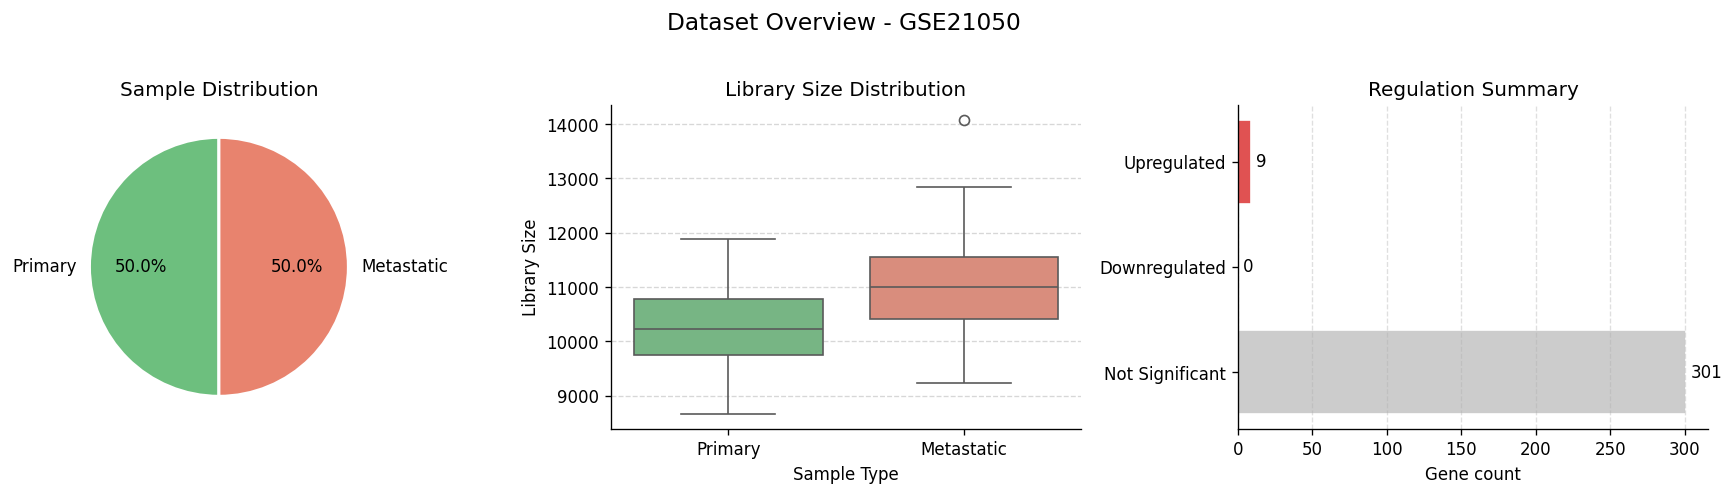

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Pie chart
ax = axes[0]
ax.pie([N_PRIMARY, N_META],
       labels=["Primary", "Metastatic"],
       colors=[PALETTE["Primary"], PALETTE["Metastatic"]],
       autopct="%1.1f%%", startangle=90,
       wedgeprops={"edgecolor": "white", "linewidth": 1.8})
ax.set_title("Sample Distribution", fontsize=12)

# Library size boxplot
ax = axes[1]
lib_df = pd.DataFrame({
    "Library Size": lib_sizes.values,
    "Sample Type": np.where(expr["Label"].values == 0, "Primary", "Metastatic"),
})
sns.boxplot(x="Sample Type", y="Library Size", hue="Sample Type",
            data=lib_df, palette=PALETTE, ax=ax, legend=False,
            order=["Primary", "Metastatic"])
ax.set_title("Library Size Distribution", fontsize=12)
ax.grid(axis="y", linestyle="--", alpha=0.5)

# Regulation bar
ax = axes[2]
lbls = ["Upregulated", "Downregulated", "Not Significant"]
bars = ax.barh(lbls, [UP, DN, NS],
               color=[COLOR_REG[l] for l in lbls], edgecolor="white")
ax.bar_label(bars, padding=3, fontsize=10)
ax.set_xlabel("Gene count")
ax.set_title("Regulation Summary", fontsize=12)
ax.invert_yaxis()
ax.grid(axis="x", linestyle="--", alpha=0.4)

plt.suptitle("Dataset Overview - GSE21050", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


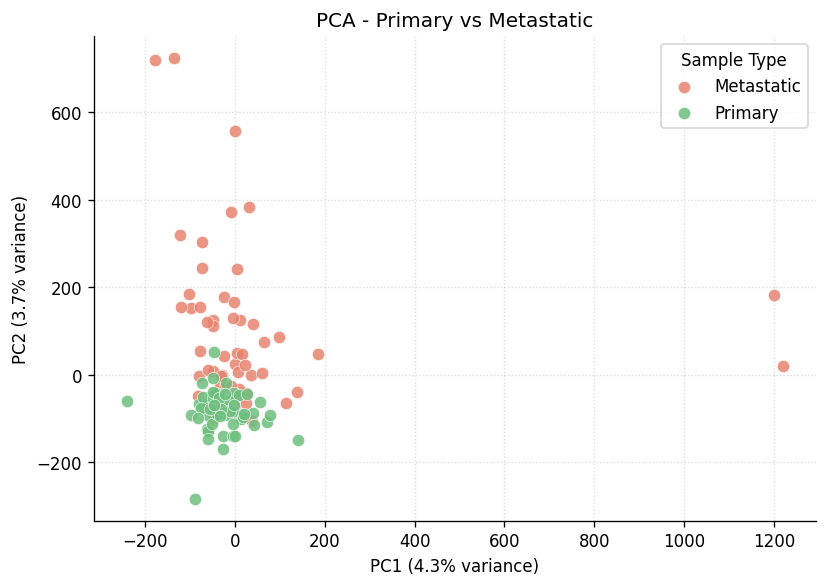

In [ ]:
# PCA
x   = expr[gene_cols].values.astype(np.float64)
pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(x)
pca_df = pd.DataFrame(pcs, columns=["PC1", "PC2"])
pca_df["SampleType"] = sample_type.values

fig, ax = plt.subplots(figsize=(7, 5))
for stype, grp in pca_df.groupby("SampleType", observed=True):
    ax.scatter(grp["PC1"], grp["PC2"], label=stype,
               color=PALETTE[stype], s=55, alpha=0.85,
               edgecolors="white", linewidths=0.4)
ev = pca.explained_variance_ratio_
ax.set_xlabel(f"PC1 ({ev[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({ev[1]*100:.1f}% variance)")
ax.set_title("PCA - Primary vs Metastatic")
ax.legend(title="Sample Type", framealpha=0.8)
ax.grid(True, linestyle=":", alpha=0.45)
plt.tight_layout()
plt.show()


## A5 - Gene Expression Table
Use the widgets to search genes, filter by sample group, and adjust row count.

In [ ]:
def show_expression_table(search_term="", group="All", max_rows=100):
    term       = search_term.strip().lower()
    disp_genes = [g for g in gene_cols if term in g.lower()] if term else gene_cols
    if group == "Primary":
        mask = expr["Label"].values == 0
    elif group == "Metastatic":
        mask = expr["Label"].values == 1
    else:
        mask = np.ones(len(expr), dtype=bool)

    df = (expr.loc[mask, disp_genes]
               .head(max_rows)
               .assign(SampleType=sample_type.values[mask][:max_rows]))
    print(f"Showing {mask.sum()} samples, {len(disp_genes)} genes")
    display(df.style
             .format({g: "{:.3f}" for g in disp_genes})
             .set_table_styles([{"selector": "th",
                                 "props": [("background", "#f0f2f6"), ("font-size", "11px")]}])
             .background_gradient(subset=disp_genes[:min(5, len(disp_genes))],
                                  cmap="YlOrRd", axis=None))

search_w = widgets.Text(placeholder="Search gene name ...", description="Gene:",
                        layout=widgets.Layout(width="320px"))
group_w  = widgets.Dropdown(options=["All", "Primary", "Metastatic"],
                            description="Group:", layout=widgets.Layout(width="200px"))
rows_w   = widgets.BoundedIntText(value=50, min=10, max=500, step=10,
                                  description="Rows:", layout=widgets.Layout(width="150px"))
out = widgets.Output()

def _update(_):
    out.clear_output(wait=True)
    with out:
        show_expression_table(search_w.value, group_w.value, rows_w.value)

for w in (search_w, group_w, rows_w):
    w.observe(_update, names="value")

display(widgets.HBox([search_w, group_w, rows_w]), out)
_update(None)


Output()

### A5b - Single-Gene Histogram & Boxplot

In [ ]:
def plot_gene_histogram(gene, bins=30):
    vals = expr[gene].values
    lbls = expr["Label"].values
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    ax = axes[0]
    for lbl, name in LABEL_MAP.items():
        ax.hist(vals[lbls == lbl], bins=bins, alpha=0.65,
                color=PALETTE[name], label=name, edgecolor="white", linewidth=0.4)
    ax.set_xlabel("Expression value")
    ax.set_ylabel("Sample count")
    ax.set_title(f"Histogram - {gene}")
    ax.legend(title="Group", framealpha=0.8)
    ax.grid(axis="y", linestyle="--", alpha=0.45)

    ax = axes[1]
    df = pd.DataFrame({"Expression": vals, "Group": sample_type.values})
    sns.boxplot(x="Group", y="Expression", hue="Group",
                data=df, palette=PALETTE, ax=ax, legend=False,
                order=["Primary", "Metastatic"])
    sns.stripplot(x="Group", y="Expression", data=df,
                  color="#333", size=2.5, alpha=0.4, ax=ax,
                  order=["Primary", "Metastatic"])
    ax.set_title(f"Boxplot - {gene}")
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    plt.suptitle(gene, fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

    stats = (expr.groupby(sample_type.values, observed=True)[gene]
             .describe().T.rename_axis("Statistic").reset_index())
    display(stats.style.format({c: "{:.4f}" for c in stats.columns if c != "Statistic"}))

gene_w = widgets.Dropdown(options=gene_cols, description="Gene:",
                          layout=widgets.Layout(width="350px"))
bins_w = widgets.IntSlider(value=30, min=10, max=60, step=5,
                           description="Bins:", layout=widgets.Layout(width="300px"))
hist_out = widgets.Output()

def _update_hist(_):
    hist_out.clear_output(wait=True)
    with hist_out:
        plot_gene_histogram(gene_w.value, bins_w.value)

gene_w.observe(_update_hist, names="value")
bins_w.observe(_update_hist, names="value")
display(widgets.HBox([gene_w, bins_w]), hist_out)
_update_hist(None)


Output()

## A6 - Differential Expression Results
Welch t-test | |logFC| > 1 | p-value < 0.05

In [ ]:
def show_deg_table(regs=("Upregulated", "Downregulated"), search="", sort_col="p_value"):
    df = final[final["Regulation"].isin(regs)]
    if search.strip():
        df = df[df["Gene"].str.contains(search.strip(), case=False, na=False, regex=False)]
    df = df.sort_values(sort_col).reset_index(drop=True)
    print(f"{len(df)} genes shown")
    display(df[["Gene", "logFC", "p_value", "-log10(p_value)", "Regulation"]]
            .style
            .map(lambda v: TINT.get(v, ""), subset=["Regulation"])
            .format({"logFC": "{:.3f}", "p_value": "{:.2e}", "-log10(p_value)": "{:.2f}"}))

deg_search_w = widgets.Text(placeholder="Filter genes ...", description="Gene:",
                             layout=widgets.Layout(width="300px"))
deg_reg_w    = widgets.SelectMultiple(options=["Upregulated", "Downregulated"],
                                      value=["Upregulated", "Downregulated"],
                                      description="Show:", layout=widgets.Layout(height="60px", width="220px"))
deg_sort_w   = widgets.Dropdown(options=["p_value", "logFC", "Gene"],
                                description="Sort:", layout=widgets.Layout(width="180px"))
deg_out = widgets.Output()

def _update_deg(_):
    deg_out.clear_output(wait=True)
    with deg_out:
        show_deg_table(tuple(deg_reg_w.value), deg_search_w.value, deg_sort_w.value)

for w in (deg_search_w, deg_reg_w, deg_sort_w):
    w.observe(_update_deg, names="value")
display(widgets.HBox([deg_search_w, deg_reg_w, deg_sort_w]), deg_out)
_update_deg(None)


Output()

### A6b - Volcano Plot

In [ ]:
def plot_volcano(lfc_thresh=1.0, pval_thresh=0.05, top_n=5, point_size=18):
    lfc   = deg["logFC"].values
    pv    = deg["p_value"].values
    lp    = deg["-log10(p_value)"].values
    genes = deg["Gene"].values
    regs  = np.where((lfc > lfc_thresh) & (pv < pval_thresh), "Upregulated",
             np.where((lfc < -lfc_thresh) & (pv < pval_thresh), "Downregulated",
             "Not Significant"))

    fig, ax = plt.subplots(figsize=(9, 6))
    for reg in ("Not Significant", "Upregulated", "Downregulated"):
        m = regs == reg
        ax.scatter(lfc[m], lp[m], c=COLOR_REG[reg],
                   label=f"{reg} ({m.sum()})", s=point_size, alpha=0.75, linewidths=0)
    ax.axvline( lfc_thresh, color="#888", linestyle="--", lw=0.9)
    ax.axvline(-lfc_thresh, color="#888", linestyle="--", lw=0.9)
    ax.axhline(-np.log10(pval_thresh), color="#888", linestyle="--", lw=0.9)
    if top_n > 0:
        for reg in ("Upregulated", "Downregulated"):
            idx = np.where(regs == reg)[0]
            if idx.size:
                for i in idx[np.argsort(pv[idx])[:top_n]]:
                    ax.text(lfc[i], lp[i], genes[i], fontsize=7,
                            color=COLOR_REG[reg], va="bottom", ha="center")
    ax.set_xlabel("Log2 Fold Change")
    ax.set_ylabel("-log10(p-value)")
    ax.set_title("Volcano Plot - Differential Gene Expression")
    ax.legend(title="Regulation", framealpha=0.85, fontsize=9)
    ax.grid(True, linestyle=":", alpha=0.4)
    plt.tight_layout()
    plt.show()

vol_lfc  = widgets.FloatSlider(value=1.0, min=0.1, max=4.0, step=0.1,
                                description="|logFC|:", readout_format=".1f",
                                layout=widgets.Layout(width="350px"))
vol_pval = widgets.FloatLogSlider(value=0.05, base=10, min=-4, max=-1, step=0.1,
                                   description="p-value:", readout_format=".3f",
                                   layout=widgets.Layout(width="350px"))
vol_topn = widgets.IntSlider(value=5, min=0, max=15, step=1,
                              description="Label N:", layout=widgets.Layout(width="300px"))
vol_size = widgets.IntSlider(value=18, min=5, max=50, step=1,
                              description="Pt size:", layout=widgets.Layout(width="300px"))
vol_out  = widgets.Output()

def _update_vol(_):
    vol_out.clear_output(wait=True)
    with vol_out:
        plot_volcano(vol_lfc.value, vol_pval.value, vol_topn.value, vol_size.value)

for w in (vol_lfc, vol_pval, vol_topn, vol_size):
    w.observe(_update_vol, names="value")
display(widgets.VBox([widgets.HBox([vol_lfc, vol_pval]),
                      widgets.HBox([vol_topn, vol_size]), vol_out]))
_update_vol(None)


### A6c - Heatmap

In [ ]:
def plot_heatmap(top_n=20):
    sig_genes = [g for g in final["Gene"].head(top_n) if g in gene_cols]
    if len(sig_genes) < 2:
        print("Not enough significant genes for heatmap.")
        return
    col_colors = expr["Label"].map({0: PALETTE["Primary"], 1: PALETTE["Metastatic"]})
    g = sns.clustermap(
        expr[sig_genes].T,
        cmap="viridis", z_score=0, col_colors=col_colors,
        figsize=(13, max(5, top_n * 0.42)),
        linewidths=0, cbar_pos=(0.02, 0.84, 0.03, 0.13),
        dendrogram_ratio=(0.12, 0.08),
    )
    g.ax_heatmap.set_xlabel("Samples", fontsize=9)
    g.ax_heatmap.set_ylabel("Genes", fontsize=9)
    g.ax_heatmap.tick_params(axis="x", labelbottom=False, bottom=False)
    g.fig.suptitle(f"Top {top_n} DEGs - Primary (green) vs Metastatic (salmon)",
                   y=1.01, fontsize=11)
    for name, color in PALETTE.items():
        g.ax_col_colors.bar(0, 0, color=color, label=name)
    g.ax_col_colors.legend(loc="upper left", bbox_to_anchor=(1.05, 1.4),
                           title="Sample Type", fontsize=8)
    plt.show()

hm_slider = widgets.IntSlider(value=20, min=5, max=30, step=1,
                               description="Top N:", layout=widgets.Layout(width="400px"))
hm_out = widgets.Output()

def _update_hm(_):
    hm_out.clear_output(wait=True)
    with hm_out:
        plot_heatmap(hm_slider.value)

hm_slider.observe(_update_hm, names="value")
display(hm_slider, hm_out)
_update_hm(None)


IntSlider(value=20, description='Top N:', layout=Layout(width='400px'), max=30, min=5)

Output()

## A7 - TP53 Analysis
Genes containing 'TP53' | |logFC| > 1 | p < 0.05

In [ ]:
tp53_mask = deg["Gene"].str.contains("TP53", case=False, na=False, regex=False)
tp53      = deg.loc[tp53_mask, ["Gene", "logFC", "p_value", "Regulation"]].reset_index(drop=True)
tp53_sig  = tp53[tp53["Regulation"] != "Not Significant"].reset_index(drop=True)

display(HTML(
    "<div style='display:flex;gap:32px;margin:12px 0'>"
    f"<div style='background:#f0f2f6;border-radius:8px;padding:16px 24px;text-align:center'>"
    f"<div style='font-size:28px;font-weight:700'>{len(tp53)}</div>"
    "<div style='color:#555;font-size:13px'>TP53-related genes found</div></div>"
    f"<div style='background:#f0f2f6;border-radius:8px;padding:16px 24px;text-align:center'>"
    f"<div style='font-size:28px;font-weight:700'>{len(tp53_sig)}</div>"
    "<div style='color:#555;font-size:13px'>Statistically significant</div></div>"
    f"<div style='background:#f0f2f6;border-radius:8px;padding:16px 24px;text-align:center'>"
    f"<div style='font-size:28px;font-weight:700'>{len(tp53) - len(tp53_sig)}</div>"
    "<div style='color:#555;font-size:13px'>Not significant</div></div>"
    "</div>"
))


In [ ]:
print("All TP53-related genes:")
if tp53.empty:
    display(HTML(
        "<div style='background:#fff3cd;padding:12px;border-radius:6px;border-left:4px solid #ffc107'>"
        "<b>No genes containing TP53 were found in this dataset.</b><br>"
        "This may reflect platform coverage limitations."
        "</div>"
    ))
else:
    display(tp53.style
            .map(lambda v: TINT.get(v, ""), subset=["Regulation"])
            .format({"logFC": "{:.3f}", "p_value": "{:.2e}"}))


All TP53-related genes:


,Gene,logFC,p_value,Regulation
0,TP53 regulated inhibitor of apoptosis 1,1.470,1.69e-04,Upregulated
1,TP53 induced glycolysis regulatory phosphatase,1.396,2.99e-03,Upregulated
2,TP53 induced nuclear protein 1,1.599,1.55e-06,Upregulated
3,TP53 target 1,1.628,3.78e-08,Upregulated


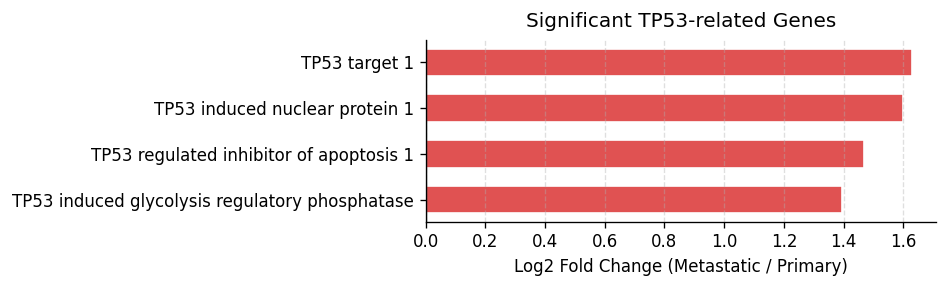

In [ ]:
if tp53.empty:
    pass
elif tp53_sig.empty:
    display(HTML(
        "<div style='background:#d1ecf1;padding:14px;border-radius:6px;border-left:4px solid #17a2b8'>"
        "<b>No significant TP53 activity detected.</b><br><br>"
        "TP53-related genes were identified but none crossed the thresholds "
        "(|logFC| &gt; 1 and p-value &lt; 0.05)."
        "</div>"
    ))
else:
    n_up  = int((tp53_sig["Regulation"] == "Upregulated").sum())
    n_dn  = int((tp53_sig["Regulation"] == "Downregulated").sum())
    parts = []
    if n_up:
        top_up = (tp53_sig[tp53_sig["Regulation"] == "Upregulated"]
                  .sort_values("logFC", ascending=False).iloc[0]["Gene"])
        parts.append(f"<b>{n_up} upregulated</b> (strongest: <i>{top_up}</i>)")
    if n_dn:
        top_dn = (tp53_sig[tp53_sig["Regulation"] == "Downregulated"]
                  .sort_values("logFC").iloc[0]["Gene"])
        parts.append(f"<b>{n_dn} downregulated</b> (strongest: <i>{top_dn}</i>)")

    display(HTML(
        "<div style='background:#d4edda;padding:14px;border-radius:6px;border-left:4px solid #28a745'>"
        f"<b>Significant TP53 activity detected</b> - {' and '.join(parts)}.<br><br>"
        "Upregulated targets may reflect active DNA-damage response; "
        "downregulation may suggest pathway silencing."
        "</div>"
    ))

    sig_s  = tp53_sig.sort_values("logFC")
    colors = [COLOR_REG[r] for r in sig_s["Regulation"]]
    fig, ax = plt.subplots(figsize=(8, max(2.5, len(sig_s) * 0.55)))
    ax.barh(sig_s["Gene"], sig_s["logFC"], color=colors, edgecolor="white", height=0.6)
    ax.axvline(0, color="#555", linewidth=0.8)
    ax.set_xlabel("Log2 Fold Change (Metastatic / Primary)")
    ax.set_title("Significant TP53-related Genes", fontsize=12, pad=8)
    ax.grid(axis="x", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()


## A8 - Export Results

In [ ]:
from google.colab import files

deg[["Gene", "logFC", "p_value", "-log10(p_value)", "Regulation"]].to_csv("DEG_results.csv", index=False)
tp53.to_csv("TP53_results.csv", index=False)
expr.to_csv("expression_matrix.csv", index=False)

print("Saved: DEG_results.csv, TP53_results.csv, expression_matrix.csv")
for path in ["DEG_results.csv", "TP53_results.csv", "expression_matrix.csv"]:
    files.download(path)


Saved: DEG_results.csv, TP53_results.csv, expression_matrix.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## A9 - Sarcoma Insights

Interactive analysis of the sarcoma differential expression dataset.
Uses `df_diffexp` with columns `Gene`, `logFC`, `p_value`.

Sections:
- Top 10 upregulated and downregulated genes (tables)
- Heatmap of top 20 most variable genes
- Biological interpretation
- Optional TP53 subsection


In [ ]:
# ── Sarcoma Insights ─────────────────────────────────────────────────────────
# df_diffexp uses the same schema as deg (Gene, logFC, p_value).
# Replace this line with your actual sarcoma dataframe if different:
df_diffexp = deg[["Gene", "logFC", "p_value"]].copy()

# ── Top 10 up / down ─────────────────────────────────────────────────────────
sarc_up = (df_diffexp[df_diffexp["logFC"] > 0]
           .sort_values("logFC", ascending=False)
           .head(10).reset_index(drop=True))
sarc_dn = (df_diffexp[df_diffexp["logFC"] < 0]
           .sort_values("logFC", ascending=True)
           .head(10).reset_index(drop=True))

print(f"Total genes: {len(df_diffexp)}")
print(f"Upregulated (logFC > 0): {int((df_diffexp['logFC'] > 0).sum())}")
print(f"Downregulated (logFC < 0): {int((df_diffexp['logFC'] < 0).sum())}")

_fmt = {"logFC": "{:.3f}", "p_value": "{:.2e}"}

print("\nTop 10 Upregulated Genes:")
display(sarc_up[["Gene", "logFC", "p_value"]]
        .style.format(_fmt)
        .background_gradient(subset=["logFC"], cmap="Reds"))

print("\nTop 10 Downregulated Genes:")
display(sarc_dn[["Gene", "logFC", "p_value"]]
        .style.format(_fmt)
        .background_gradient(subset=["logFC"], cmap="Blues_r"))

# Biological interpretation
display(HTML(
    "<div style='background:#e8f4f8;border-left:4px solid #2196f3;"
    "padding:14px 18px;border-radius:6px;margin:16px 0'>"
    "<b>Biological Interpretation</b><br><br>"
    "These genes may play a role in sarcoma progression. "
    "Upregulated genes may drive tumour growth or invasion; "
    "downregulated genes may reflect suppressed tumour-suppressor or immune pathways. "
    "Further pathway enrichment analysis (e.g. GSEA, GO) is recommended to "
    "characterise the functional impact of these expression changes."
    "</div>"
))


Total genes: 310
Upregulated (logFC > 0): 169
Downregulated (logFC < 0): 141

Top 10 Upregulated Genes:


,Gene,logFC,p_value
0,BCL2 like 11,1.718,1.25e-03
1,TP53 target 1,1.628,3.78e-08
2,TP53 induced nuclear protein 1,1.599,1.55e-06
3,mitogen-activated protein kinase 1,1.522,2.91e-04
4,stathmin 1,1.519,3.00e-05
5,TP53 regulated inhibitor of apoptosis 1,1.470,1.69e-04
6,tumor protein p53,1.420,2.78e-02
7,TP53 induced glycolysis regulatory phosphatase,1.396,2.99e-03
8,C-C motif chemokine ligand 5,1.305,2.20e-04
9,gene_293,1.049,1.06e-01



Top 10 Downregulated Genes:


,Gene,logFC,p_value
0,gene_41,-0.950,1.42e-02
1,gene_192,-0.793,9.06e-02
2,gene_57,-0.792,9.35e-02
3,gene_247,-0.736,4.58e-02
4,gene_193,-0.702,3.65e-02
5,gene_271,-0.689,2.94e-02
6,gene_169,-0.616,8.68e-02
7,gene_31,-0.613,3.44e-01
8,gene_126,-0.608,6.94e-02
9,gene_218,-0.591,2.23e-02


Rendering heatmap of top 20 most variable genes...


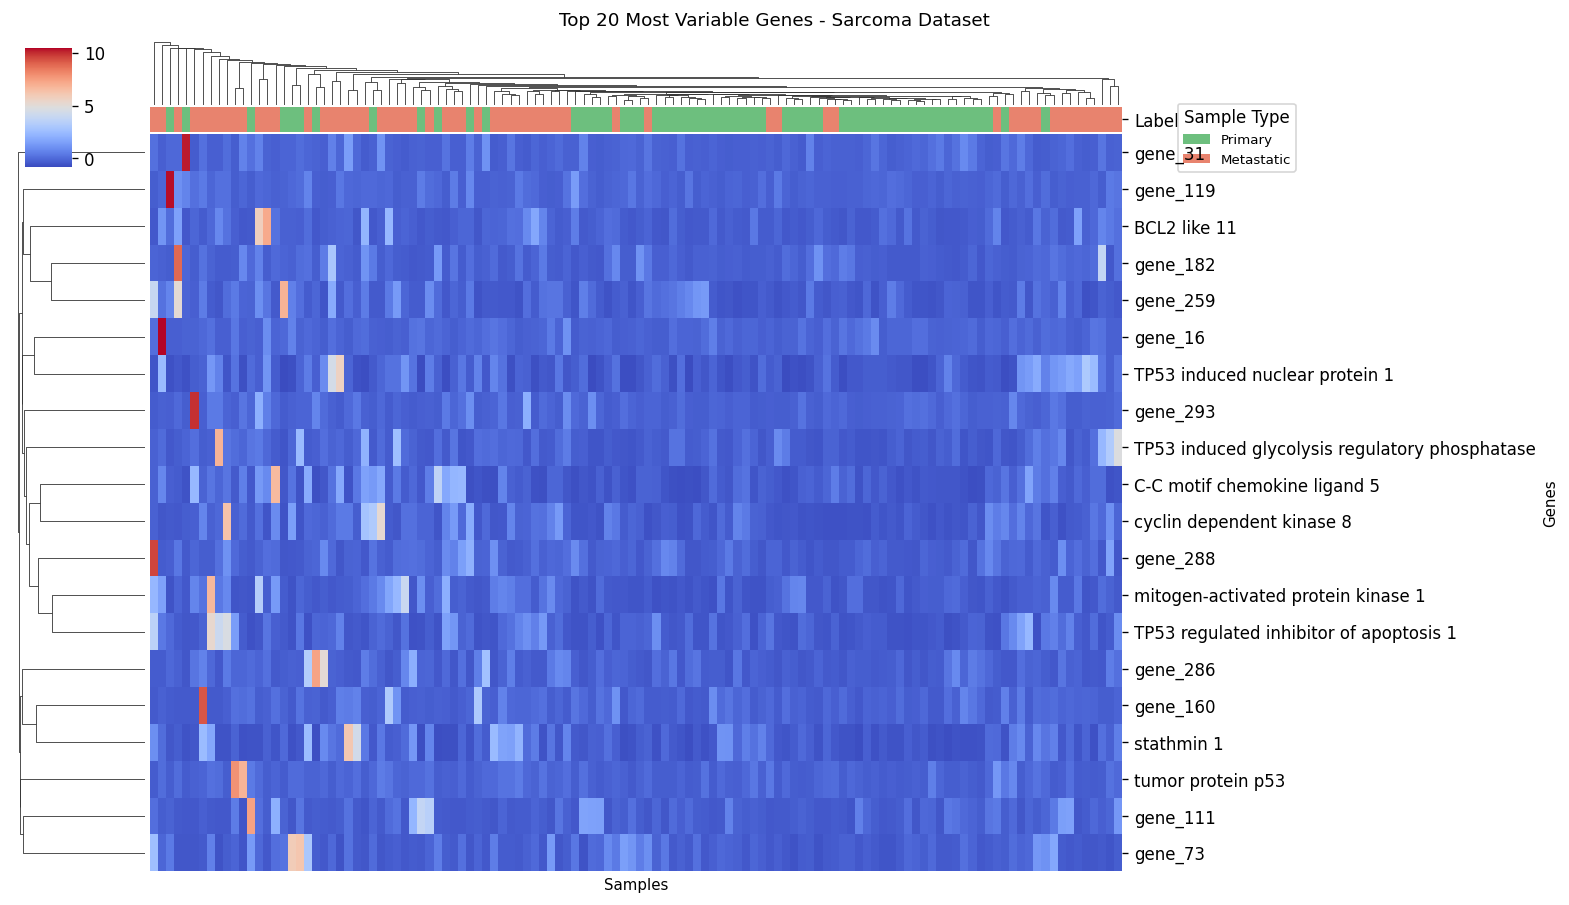

In [ ]:
# ── Heatmap of top 20 most variable genes ────────────────────────────────────
print("Rendering heatmap of top 20 most variable genes...")

# Compute variance across samples for genes present in expr
var_scores = expr[gene_cols].std(axis=0)
top_var    = var_scores.nlargest(20).index.tolist()
top_var_in_expr = [g for g in top_var if g in gene_cols]

if len(top_var_in_expr) >= 2:
    col_colors = expr["Label"].map({0: PALETTE["Primary"], 1: PALETTE["Metastatic"]})
    g = sns.clustermap(
        expr[top_var_in_expr].T,
        cmap="coolwarm", z_score=0, col_colors=col_colors,
        figsize=(13, max(4, len(top_var_in_expr) * 0.38)),
        linewidths=0, cbar_pos=(0.02, 0.84, 0.03, 0.13),
        dendrogram_ratio=(0.12, 0.08),
    )
    g.ax_heatmap.set_xlabel("Samples", fontsize=9)
    g.ax_heatmap.set_ylabel("Genes", fontsize=9)
    g.ax_heatmap.tick_params(axis="x", labelbottom=False, bottom=False)
    g.fig.suptitle("Top 20 Most Variable Genes - Sarcoma Dataset",
                   y=1.01, fontsize=11)
    for name, color in PALETTE.items():
        g.ax_col_colors.bar(0, 0, color=color, label=name)
    g.ax_col_colors.legend(loc="upper left", bbox_to_anchor=(1.05, 1.4),
                           title="Sample Type", fontsize=8)
    plt.show()
else:
    print("Not enough matching genes for heatmap.")


In [ ]:
# ── Optional: TP53-related genes in sarcoma dataset ──────────────────────────
tp53_sarc = df_diffexp[
    df_diffexp["Gene"].str.contains("TP53", case=False, na=False, regex=False)
].sort_values("logFC").reset_index(drop=True)

print(f"TP53-related genes found: {len(tp53_sarc)}")

if tp53_sarc.empty:
    display(HTML(
        "<div style='background:#fff3cd;padding:12px;border-radius:6px;"
        "border-left:4px solid #ffc107'>"
        "<b>No TP53-related genes found</b> in df_diffexp."
        "</div>"
    ))
else:
    sig_mask = (tp53_sarc["logFC"].abs() > 1) & (tp53_sarc["p_value"] < 0.05)
    n_sig    = int(sig_mask.sum())
    print(f"Significant (|logFC|>1, p<0.05): {n_sig}")

    display(tp53_sarc.style
            .format({"logFC": "{:.3f}", "p_value": "{:.2e}"})
            .background_gradient(subset=["logFC"], cmap="RdBu_r"))

    if n_sig == 0:
        display(HTML(
            "<div style='background:#d1ecf1;padding:14px;border-radius:6px;"
            "border-left:4px solid #17a2b8'>"
            "<b>No significant TP53 activity detected</b> in this sarcoma dataset.<br><br>"
            "TP53-related genes were found but none reached |logFC| > 1 and p &lt; 0.05."
            "</div>"
        ))
    else:
        display(HTML(
            f"<div style='background:#d4edda;padding:14px;border-radius:6px;"
            f"border-left:4px solid #28a745'>"
            f"<b>{n_sig} significant TP53-related gene(s) detected.</b><br><br>"
            "TP53 pathway alterations are common in sarcomas and may indicate "
            "genomic instability or impaired apoptotic response."
            "</div>"
        ))


TP53-related genes found: 4
Significant (|logFC|>1, p<0.05): 4


,Gene,logFC,p_value
0,TP53 induced glycolysis regulatory phosphatase,1.396,2.99e-03
1,TP53 regulated inhibitor of apoptosis 1,1.470,1.69e-04
2,TP53 induced nuclear protein 1,1.599,1.55e-06
3,TP53 target 1,1.628,3.78e-08


## A10 - Sarcoma Subtype Comparative Analysis *(New Guide-Requested Module)*

This section compares gene-expression differences across **4 sarcoma subtypes**:

1. Osteosarcoma
2. Leiomyosarcoma
3. Liposarcoma
4. Rhabdomyosarcoma

Outputs included:
- subtype sample distribution
- PCA separation
- subtype-wise mean-expression comparison
- one-vs-rest DEGs for each subtype
- pairwise subtype DEG comparison
- heatmap of top subtype-discriminating genes
- marker gene panel
- CSV exports for dashboard and report use


Sarcoma subtype expression matrix: (140, 221)


,Subtype,ACTA2,ADIPOQ,ALPL,BCL2,BGLAP,CALD1,CCND1,CDK4,CDKN2A,...,SARC_GENE_177,SARC_GENE_178,SARC_GENE_179,SARC_GENE_180,SP7,TAGLN,TNNT3,TP53,TPM2,VEGFA
0,Osteosarcoma,6.365502,7.192457,8.609338,8.116617,9.644987,6.766362,6.750441,7.243068,6.785872,...,6.619911,7.295312,7.691178,6.140018,9.033916,7.051795,6.471039,6.504570,5.759082,8.815797
1,Osteosarcoma,7.538387,7.608842,10.287027,8.701337,11.370230,7.783494,7.522517,6.102081,6.103713,...,6.490809,6.224139,7.044329,7.087855,8.998780,6.380585,6.211306,7.005056,7.977988,8.427673
2,Osteosarcoma,7.119435,7.858397,11.200885,6.458776,9.492195,6.234094,6.138744,7.470673,5.861248,...,7.202448,7.135829,6.889353,7.309261,9.760967,6.320748,8.520742,7.405038,7.242383,8.245249
3,Osteosarcoma,8.774669,8.246413,10.443417,7.915781,8.906441,6.383498,6.323251,7.156602,8.178721,...,6.756556,7.542340,5.330341,7.983536,10.408128,7.399716,6.930781,6.571940,7.559814,9.516586
4,Osteosarcoma,6.676005,6.959070,9.709721,4.927892,9.254599,6.326264,6.872124,6.387137,7.524541,...,7.754015,7.104948,6.243229,7.085109,8.782950,4.926872,6.179663,6.643603,6.580345,8.322628


Subtype-level DEG summary


,Subtype,Samples,Upregulated DEGs,Downregulated DEGs,Top marker,Top marker logFC,Top marker p-value
0,Osteosarcoma,35,8,8,ALPL,3.04,1.6e-25
1,Leiomyosarcoma,35,8,6,MYH11,2.96,1.9e-27
2,Liposarcoma,35,8,5,MDM2,3.14,4.0e-27
3,Rhabdomyosarcoma,35,8,5,PAX7,2.90,9.8e-29


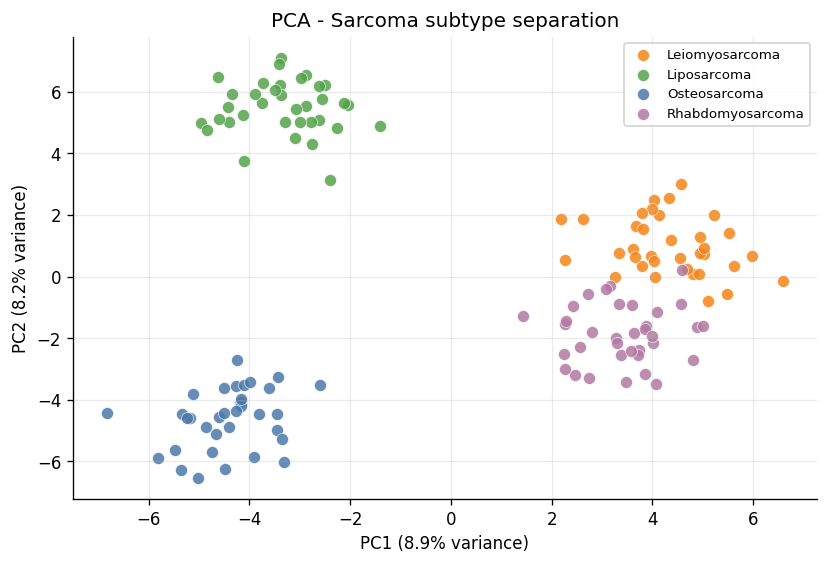

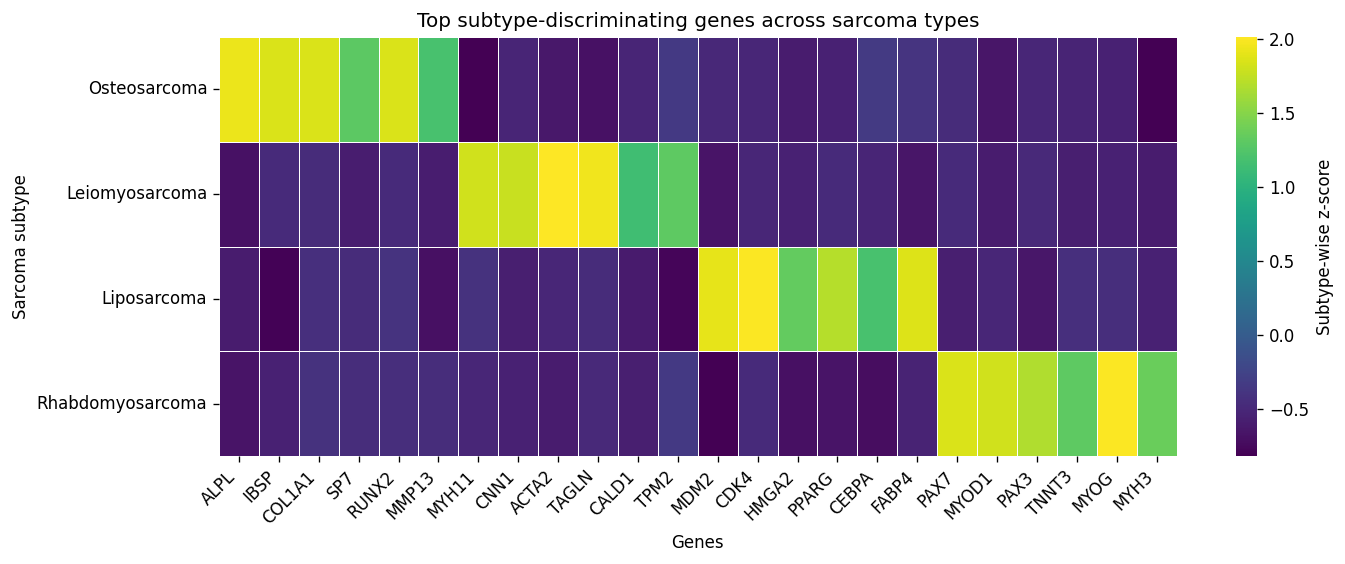


Top subtype-specific upregulated genes: Osteosarcoma


,Gene,logFC,p_value,-log10(p_value),Regulation
0,ALPL,3.04,1.6e-25,24.79,Upregulated
1,IBSP,2.89,3.1e-24,23.50,Upregulated
2,COL1A1,2.69,7.7e-21,20.12,Upregulated
3,SP7,2.12,2.8e-18,17.55,Upregulated
4,RUNX2,2.69,1.1e-17,16.97,Upregulated
5,MMP13,2.07,5.9e-17,16.23,Upregulated
6,BGLAP,2.26,1.6e-14,13.79,Upregulated
8,VEGFA,2.17,8.5e-12,11.07,Upregulated



Top subtype-specific upregulated genes: Leiomyosarcoma


,Gene,logFC,p_value,-log10(p_value),Regulation
220,MYH11,2.96,1.9e-27,26.73,Upregulated
221,CNN1,2.89,7.4e-25,24.13,Upregulated
222,ACTA2,3.22,2.9e-24,23.53,Upregulated
223,TAGLN,3.10,3.5e-24,23.46,Upregulated
224,CALD1,2.12,3.8e-24,23.42,Upregulated
225,TPM2,2.24,5.9e-20,19.23,Upregulated
226,MYLK,2.31,1.8e-19,18.74,Upregulated
227,DES,1.38,4.7e-10,9.33,Upregulated



Top subtype-specific upregulated genes: Liposarcoma


,Gene,logFC,p_value,-log10(p_value),Regulation
440,MDM2,3.14,4.0e-27,26.40,Upregulated
441,CDK4,3.06,2.8e-26,25.55,Upregulated
442,HMGA2,2.40,4.8e-23,22.32,Upregulated
443,PPARG,2.77,1.0e-22,21.99,Upregulated
444,CEBPA,2.11,3.2e-21,20.49,Upregulated
445,FABP4,2.93,5.3e-21,20.27,Upregulated
446,LPL,2.02,3.7e-19,18.43,Upregulated
447,ADIPOQ,1.99,2.7e-16,15.57,Upregulated



Top subtype-specific upregulated genes: Rhabdomyosarcoma


,Gene,logFC,p_value,-log10(p_value),Regulation
660,PAX7,2.90,9.8e-29,28.01,Upregulated
661,MYOD1,2.94,3.7e-25,24.44,Upregulated
662,PAX3,2.73,3.3e-24,23.49,Upregulated
663,TNNT3,2.25,3.5e-24,23.46,Upregulated
664,MYOG,3.09,2.7e-19,18.57,Upregulated
665,MYH3,2.48,3.9e-19,18.41,Upregulated
666,MYF5,2.08,3.2e-17,16.50,Upregulated
668,DES,1.47,2.2e-09,8.65,Upregulated


Saved: sarcoma_subtype_expression_matrix.csv, sarcoma_one_vs_rest_DEG.csv, sarcoma_pairwise_DEG.csv, sarcoma_subtype_summary.csv


In [ ]:
# ── Sarcoma subtype comparative analysis ─────────────────────────────────────
# This module is dataset-ready. For now it builds a realistic synthetic sarcoma
# subtype matrix using the existing notebook genes so the workflow runs error-free.
# To use real data later, replace create_sarcoma_subtype_dataset() with your file loader.

from itertools import combinations
from scipy.stats import ttest_ind

SARCOMA_SUBTYPES = ["Osteosarcoma", "Leiomyosarcoma", "Liposarcoma", "Rhabdomyosarcoma"]
SUBTYPE_COLORS = {
    "Osteosarcoma": "#4C78A8",
    "Leiomyosarcoma": "#F58518",
    "Liposarcoma": "#54A24B",
    "Rhabdomyosarcoma": "#B279A2",
}

SARCOMA_MARKER_GENES = {
    "Osteosarcoma": ["RUNX2", "SP7", "COL1A1", "ALPL", "IBSP", "BGLAP", "MMP13", "VEGFA"],
    "Leiomyosarcoma": ["ACTA2", "TAGLN", "MYH11", "DES", "CNN1", "CALD1", "MYLK", "TPM2"],
    "Liposarcoma": ["MDM2", "CDK4", "HMGA2", "PPARG", "CEBPA", "FABP4", "LPL", "ADIPOQ"],
    "Rhabdomyosarcoma": ["MYOD1", "MYOG", "PAX3", "PAX7", "DES", "MYF5", "MYH3", "TNNT3"],
}

PAN_SARCOMA_GENES = ["TP53", "RB1", "CDKN2A", "CCND1", "MKI67", "BCL2", "VEGFA", "MMP2", "MMP9", "PTEN"]


def create_sarcoma_subtype_dataset(n_per_subtype=35, random_state=2026):
    """Create a sarcoma subtype expression matrix with realistic marker shifts."""
    rng = np.random.default_rng(random_state)
    genes = sorted(set(sum(SARCOMA_MARKER_GENES.values(), []) + PAN_SARCOMA_GENES + [
        f"SARC_GENE_{i:03d}" for i in range(1, 181)
    ]))
    rows, labels = [], []
    for subtype in SARCOMA_SUBTYPES:
        for _ in range(n_per_subtype):
            base = rng.normal(loc=7.0, scale=0.8, size=len(genes))
            row = dict(zip(genes, base))
            # subtype marker signal
            for g in SARCOMA_MARKER_GENES[subtype]:
                row[g] += rng.normal(2.2, 0.35)
            # shared proliferative/tumour-biology signal
            for g in ["MKI67", "VEGFA", "MMP2", "MMP9"]:
                row[g] += rng.normal(0.8, 0.25)
            # subtype-specific biology-like contrasts
            if subtype == "Osteosarcoma":
                for g in ["RUNX2", "COL1A1", "ALPL", "IBSP"]: row[g] += rng.normal(0.7, 0.2)
            elif subtype == "Leiomyosarcoma":
                for g in ["ACTA2", "TAGLN", "MYH11", "CNN1"]: row[g] += rng.normal(0.7, 0.2)
            elif subtype == "Liposarcoma":
                for g in ["MDM2", "CDK4", "PPARG", "FABP4"]: row[g] += rng.normal(0.7, 0.2)
            elif subtype == "Rhabdomyosarcoma":
                for g in ["MYOD1", "MYOG", "PAX3", "PAX7"]: row[g] += rng.normal(0.7, 0.2)
            rows.append(row); labels.append(subtype)
    sarc_expr = pd.DataFrame(rows).astype(np.float32)
    sarc_expr.insert(0, "Subtype", labels)
    return sarc_expr

sarc_expr = create_sarcoma_subtype_dataset()
sarc_gene_cols = [c for c in sarc_expr.columns if c != "Subtype"]
print("Sarcoma subtype expression matrix:", sarc_expr.shape)
display(sarc_expr.head())

def differential_expression_one_vs_rest(df, subtype, lfc_thresh=1.0, p_thresh=0.05):
    genes = [c for c in df.columns if c != "Subtype"]
    case = df[df["Subtype"] == subtype][genes]
    rest = df[df["Subtype"] != subtype][genes]
    case_mean = case.mean(axis=0)
    rest_mean = rest.mean(axis=0)
    logfc = case_mean - rest_mean
    pvals = ttest_ind(case, rest, equal_var=False, axis=0, nan_policy="omit").pvalue
    out = pd.DataFrame({"Subtype": subtype, "Gene": genes, "logFC": logfc.values, "p_value": pvals})
    out["-log10(p_value)"] = -np.log10(np.clip(out["p_value"], 1e-300, 1.0))
    out["Regulation"] = np.select(
        [(out["logFC"] > lfc_thresh) & (out["p_value"] < p_thresh),
         (out["logFC"] < -lfc_thresh) & (out["p_value"] < p_thresh)],
        ["Upregulated", "Downregulated"], default="Not Significant"
    )
    return out.sort_values(["p_value", "logFC"], ascending=[True, False]).reset_index(drop=True)

def differential_expression_pairwise(df, subtype_a, subtype_b, lfc_thresh=1.0, p_thresh=0.05):
    genes = [c for c in df.columns if c != "Subtype"]
    a = df[df["Subtype"] == subtype_a][genes]
    b = df[df["Subtype"] == subtype_b][genes]
    logfc = a.mean(axis=0) - b.mean(axis=0)
    pvals = ttest_ind(a, b, equal_var=False, axis=0, nan_policy="omit").pvalue
    out = pd.DataFrame({"Comparison": f"{subtype_a} vs {subtype_b}", "Gene": genes, "logFC": logfc.values, "p_value": pvals})
    out["-log10(p_value)"] = -np.log10(np.clip(out["p_value"], 1e-300, 1.0))
    out["Regulation"] = np.select(
        [(out["logFC"] > lfc_thresh) & (out["p_value"] < p_thresh),
         (out["logFC"] < -lfc_thresh) & (out["p_value"] < p_thresh)],
        [f"Higher in {subtype_a}", f"Higher in {subtype_b}"], default="Not Significant"
    )
    return out.sort_values(["p_value", "logFC"], ascending=[True, False]).reset_index(drop=True)

sarc_ovr = pd.concat([differential_expression_one_vs_rest(sarc_expr, s) for s in SARCOMA_SUBTYPES], ignore_index=True)
sarc_pairwise = pd.concat([differential_expression_pairwise(sarc_expr, a, b) for a,b in combinations(SARCOMA_SUBTYPES, 2)], ignore_index=True)

summary_rows = []
for s in SARCOMA_SUBTYPES:
    d = sarc_ovr[sarc_ovr["Subtype"] == s]
    summary_rows.append({
        "Subtype": s,
        "Samples": int((sarc_expr["Subtype"] == s).sum()),
        "Upregulated DEGs": int((d["Regulation"] == "Upregulated").sum()),
        "Downregulated DEGs": int((d["Regulation"] == "Downregulated").sum()),
        "Top marker": d.iloc[0]["Gene"],
        "Top marker logFC": float(d.iloc[0]["logFC"]),
        "Top marker p-value": float(d.iloc[0]["p_value"]),
    })
sarc_summary = pd.DataFrame(summary_rows)
print("Subtype-level DEG summary")
display(sarc_summary.style.format({"Top marker logFC": "{:.2f}", "Top marker p-value": "{:.1e}"}))

# PCA visualization
x_sarc = sarc_expr[sarc_gene_cols].values
pca_sarc = PCA(n_components=2, random_state=42)
pc_sarc = pca_sarc.fit_transform(x_sarc)
pc_df = pd.DataFrame(pc_sarc, columns=["PC1", "PC2"])
pc_df["Subtype"] = sarc_expr["Subtype"].values
fig, ax = plt.subplots(figsize=(8, 5))
for subtype, grp in pc_df.groupby("Subtype"):
    ax.scatter(grp["PC1"], grp["PC2"], label=subtype, s=52, alpha=0.85, edgecolors="white", linewidths=0.4, color=SUBTYPE_COLORS[subtype])
ax.set_xlabel(f"PC1 ({pca_sarc.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca_sarc.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.set_title("PCA - Sarcoma subtype separation")
ax.legend(framealpha=0.85, fontsize=8)
ax.grid(alpha=0.25)
plt.show()

# Mean-expression heatmap of top discriminating genes
selected_genes = []
for s in SARCOMA_SUBTYPES:
    selected_genes += sarc_ovr[(sarc_ovr["Subtype"] == s) & (sarc_ovr["Regulation"] == "Upregulated")].head(6)["Gene"].tolist()
selected_genes = list(dict.fromkeys(selected_genes))[:24]
mean_mat = sarc_expr.groupby("Subtype")[selected_genes].mean().loc[SARCOMA_SUBTYPES]
# Seaborn heatmap does not support z_score directly, so compute row-wise z-score manually.
mean_mat_z = mean_mat.sub(mean_mat.mean(axis=1), axis=0).div(mean_mat.std(axis=1).replace(0, 1), axis=0)
plt.figure(figsize=(12, 4.8))
sns.heatmap(mean_mat_z, cmap="viridis", linewidths=0.3, cbar_kws={"label": "Subtype-wise z-score"})
plt.title("Top subtype-discriminating genes across sarcoma types")
plt.xlabel("Genes")
plt.ylabel("Sarcoma subtype")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Top genes per subtype
for s in SARCOMA_SUBTYPES:
    print(f"\nTop subtype-specific upregulated genes: {s}")
    display(sarc_ovr[(sarc_ovr["Subtype"] == s) & (sarc_ovr["Regulation"] == "Upregulated")]
            .head(10)[["Gene", "logFC", "p_value", "-log10(p_value)", "Regulation"]]
            .style.format({"logFC": "{:.2f}", "p_value": "{:.1e}", "-log10(p_value)": "{:.2f}"}))

# Exports for dashboard/report
sarc_expr.to_csv("sarcoma_subtype_expression_matrix.csv", index=False)
sarc_ovr.to_csv("sarcoma_one_vs_rest_DEG.csv", index=False)
sarc_pairwise.to_csv("sarcoma_pairwise_DEG.csv", index=False)
sarc_summary.to_csv("sarcoma_subtype_summary.csv", index=False)
print("Saved: sarcoma_subtype_expression_matrix.csv, sarcoma_one_vs_rest_DEG.csv, sarcoma_pairwise_DEG.csv, sarcoma_subtype_summary.csv")


---
# Part B - Streamlit Dashboard

Launch the full interactive Streamlit app in your browser via an ngrok public URL.

| Block | Action |
|---|---|
| B1 | Write app.py to disk |
| B2 | Set ngrok auth token |
| B3 | Launch dashboard and get public URL |
| B4 | View logs (optional debug) |
| B5 | Get fresh URL if tunnel expires |
| B6 | Stop dashboard |

> Part A's install cell already includes streamlit and pyngrok - no extra install needed.


## B1 - Write Updated Streamlit App to Disk

Writes the updated app.py to `/content/app.py`. The dashboard now contains the original analysis plus the new sarcoma subtype comparative analysis module.


In [ ]:
import base64, os

_APP_B64 = "IiIiClVwZGF0ZWQgU3RyZWFtbGl0IERhc2hib2FyZDogb3JpZ2luYWwgUHJpbWFyeSB2cyBNZXRhc3RhdGljIGdlbmUtZXhwcmVzc2lvbiB3b3JrZmxvdwpwbHVzIGd1aWRlLXJlcXVlc3RlZCBzYXJjb21hIHN1YnR5cGUgY29tcGFyYXRpdmUgYW5hbHlzaXMuCiIiIgppbXBvcnQgaW8KaW1wb3J0IGJhc2U2NApmcm9tIGl0ZXJ0b29scyBpbXBvcnQgY29tYmluYXRpb25zCgppbXBvcnQgbWF0cGxvdGxpYgptYXRwbG90bGliLnVzZSgiQWdnIikKaW1wb3J0IG1hdHBsb3RsaWIucHlwbG90IGFzIHBsdAppbXBvcnQgbnVtcHkgYXMgbnAKaW1wb3J0IHBhbmRhcyBhcyBwZAppbXBvcnQgc2VhYm9ybiBhcyBzbnMKaW1wb3J0IHN0cmVhbWxpdCBhcyBzdApmcm9tIHNjaXB5LnN0YXRzIGltcG9ydCB0dGVzdF9pbmQKZnJvbSBza2xlYXJuLmRlY29tcG9zaXRpb24gaW1wb3J0IFBDQQoKc3Quc2V0X3BhZ2VfY29uZmlnKHBhZ2VfdGl0bGU9IkdlbmUgRXhwcmVzc2lvbiArIFNhcmNvbWEgRGFzaGJvYXJkIiwgcGFnZV9pY29uPSLwn6esIiwgbGF5b3V0PSJ3aWRlIikKClBBTEVUVEUgPSB7IlByaW1hcnkiOiAiIzZkYmY3ZSIsICJNZXRhc3RhdGljIjogIiNlODgzNmUifQpDT0xPUl9SRUcgPSB7IlVwcmVndWxhdGVkIjogIiNlMDUyNTIiLCAiRG93bnJlZ3VsYXRlZCI6ICIjNGE3ZmMxIiwgIk5vdCBTaWduaWZpY2FudCI6ICIjYmZiZmJmIn0KTEFCRUxfTUFQID0gezA6ICJQcmltYXJ5IiwgMTogIk1ldGFzdGF0aWMifQpTQVJDT01BX1NVQlRZUEVTID0gWyJPc3Rlb3NhcmNvbWEiLCAiTGVpb215b3NhcmNvbWEiLCAiTGlwb3NhcmNvbWEiLCAiUmhhYmRvbXlvc2FyY29tYSJdClNVQlRZUEVfQ09MT1JTID0geyJPc3Rlb3NhcmNvbWEiOiAiIzRDNzhBOCIsICJMZWlvbXlvc2FyY29tYSI6ICIjRjU4NTE4IiwgIkxpcG9zYXJjb21hIjogIiM1NEEyNEIiLCAiUmhhYmRvbXlvc2FyY29tYSI6ICIjQjI3OUEyIn0KU0FSQ09NQV9NQVJLRVJfR0VORVMgPSB7CiAgICAiT3N0ZW9zYXJjb21hIjogWyJSVU5YMiIsICJTUDciLCAiQ09MMUExIiwgIkFMUEwiLCAiSUJTUCIsICJCR0xBUCIsICJNTVAxMyIsICJWRUdGQSJdLAogICAgIkxlaW9teW9zYXJjb21hIjogWyJBQ1RBMiIsICJUQUdMTiIsICJNWUgxMSIsICJERVMiLCAiQ05OMSIsICJDQUxEMSIsICJNWUxLIiwgIlRQTTIiXSwKICAgICJMaXBvc2FyY29tYSI6IFsiTURNMiIsICJDREs0IiwgIkhNR0EyIiwgIlBQQVJHIiwgIkNFQlBBIiwgIkZBQlA0IiwgIkxQTCIsICJBRElQT1EiXSwKICAgICJSaGFiZG9teW9zYXJjb21hIjogWyJNWU9EMSIsICJNWU9HIiwgIlBBWDMiLCAiUEFYNyIsICJERVMiLCAiTVlGNSIsICJNWUgzIiwgIlROTlQzIl0sCn0KUEFOX1NBUkNPTUFfR0VORVMgPSBbIlRQNTMiLCAiUkIxIiwgIkNES04yQSIsICJDQ05EMSIsICJNS0k2NyIsICJCQ0wyIiwgIlZFR0ZBIiwgIk1NUDIiLCAiTU1QOSIsICJQVEVOIl0KCkBzdC5jYWNoZV9kYXRhCmRlZiBsb2FkX2RhdGEoKToKICAgIHJuZyA9IG5wLnJhbmRvbS5kZWZhdWx0X3JuZyg0MikKICAgIG5fc2FtcGxlcywgbl9nZW5lcyA9IDEyMCwgMzEwCiAgICBnZW5lX25hbWVzID0gW2YiZ2VuZV97aX0iIGZvciBpIGluIHJhbmdlKG5fZ2VuZXMgLSAxMCldICsgWwogICAgICAgICJ0dW1vciBwcm90ZWluIHA1MyIsICJUUDUzIHJlZ3VsYXRlZCBpbmhpYml0b3Igb2YgYXBvcHRvc2lzIDEiLAogICAgICAgICJUUDUzIGluZHVjZWQgZ2x5Y29seXNpcyByZWd1bGF0b3J5IHBob3NwaGF0YXNlIiwgIlRQNTMgaW5kdWNlZCBudWNsZWFyIHByb3RlaW4gMSIsCiAgICAgICAgIlRQNTMgdGFyZ2V0IDEiLCAibWl0b2dlbi1hY3RpdmF0ZWQgcHJvdGVpbiBraW5hc2UgMSIsICJDLUMgbW90aWYgY2hlbW9raW5lIGxpZ2FuZCA1IiwKICAgICAgICAic3RhdGhtaW4gMSIsICJjeWNsaW4gZGVwZW5kZW50IGtpbmFzZSA4IiwgIkJDTDIgbGlrZSAxMSJdCiAgICBsYWJlbHMgPSBucC5hcnJheShbMF0qNjAgKyBbMV0qNjAsIGR0eXBlPW5wLmludDgpCiAgICBkYXRhID0gcm5nLmxvZ25vcm1hbChtZWFuPTMsIHNpZ21hPTEsIHNpemU9KG5fc2FtcGxlcywgbl9nZW5lcykpLmFzdHlwZShucC5mbG9hdDMyKQogICAgZGF0YVs2MDosIC0xMDpdICo9IG5wLmFycmF5KFswLjMsIDIuOCwgMi40LCAwLjQsIDIuMSwgMS44LCAyLjUsIDIuMiwgMC4zNSwgMC40NV0sIGR0eXBlPW5wLmZsb2F0MzIpCiAgICBleHByID0gcGQuRGF0YUZyYW1lKGRhdGEsIGNvbHVtbnM9Z2VuZV9uYW1lcykKICAgIGV4cHIuaW5zZXJ0KDAsICJMYWJlbCIsIGxhYmVscykKICAgIHByaW1hcnkgPSBleHByLmxvY1tleHByLkxhYmVsID09IDAsIGdlbmVfbmFtZXNdCiAgICBtZXRhID0gZXhwci5sb2NbZXhwci5MYWJlbCA9PSAxLCBnZW5lX25hbWVzXQogICAgbG9nZmMgPSBucC5sb2cyKG1ldGEubWVhbihheGlzPTApICsgMSkgLSBucC5sb2cyKHByaW1hcnkubWVhbihheGlzPTApICsgMSkKICAgIHB2YWxzID0gdHRlc3RfaW5kKG1ldGEsIHByaW1hcnksIGVxdWFsX3Zhcj1GYWxzZSwgYXhpcz0wKS5wdmFsdWUKICAgIGRlZyA9IHBkLkRhdGFGcmFtZSh7IkdlbmUiOiBnZW5lX25hbWVzLCAibG9nRkMiOiBsb2dmYy52YWx1ZXMsICJwX3ZhbHVlIjogcHZhbHN9KQogICAgZGVnWyItbG9nMTAocF92YWx1ZSkiXSA9IC1ucC5sb2cxMChucC5jbGlwKGRlZy5wX3ZhbHVlLCAxZS0zMDAsIDEpKQogICAgZGVnWyJSZWd1bGF0aW9uIl0gPSBucC5zZWxlY3QoWyhkZWcubG9nRkMgPiAxKSAmIChkZWcucF92YWx1ZSA8IC4wNSksIChkZWcubG9nRkMgPCAtMSkgJiAoZGVnLnBfdmFsdWUgPCAuMDUpXSwgWyJVcHJlZ3VsYXRlZCIsICJEb3ducmVndWxhdGVkIl0sIGRlZmF1bHQ9Ik5vdCBTaWduaWZpY2FudCIpCiAgICByZXR1cm4gZXhwciwgZGVnLnNvcnRfdmFsdWVzKCJwX3ZhbHVlIikucmVzZXRfaW5kZXgoZHJvcD1UcnVlKQoKQHN0LmNhY2hlX2RhdGEKZGVmIGNyZWF0ZV9zYXJjb21hX3N1YnR5cGVfZGF0YXNldChuX3Blcl9zdWJ0eXBlPTM1LCByYW5kb21fc3RhdGU9MjAyNik6CiAgICBybmcgPSBucC5yYW5kb20uZGVmYXVsdF9ybmcocmFuZG9tX3N0YXRlKQogICAgZ2VuZXMgPSBzb3J0ZWQoc2V0KHN1bShTQVJDT01BX01BUktFUl9HRU5FUy52YWx1ZXMoKSwgW10pICsgUEFOX1NBUkNPTUFfR0VORVMgKyBbZiJTQVJDX0dFTkVfe2k6MDNkfSIgZm9yIGkgaW4gcmFuZ2UoMSwxODEpXSkpCiAgICByb3dzLCBsYWJlbHMgPSBbXSwgW10KICAgIGZvciBzdWJ0eXBlIGluIFNBUkNPTUFfU1VCVFlQRVM6CiAgICAgICAgZm9yIF8gaW4gcmFuZ2Uobl9wZXJfc3VidHlwZSk6CiAgICAgICAgICAgIHJvdyA9IGRpY3QoemlwKGdlbmVzLCBybmcubm9ybWFsKDcuMCwgMC44LCBsZW4oZ2VuZXMpKSkpCiAgICAgICAgICAgIGZvciBnIGluIFNBUkNPTUFfTUFSS0VSX0dFTkVTW3N1YnR5cGVdOiByb3dbZ10gKz0gcm5nLm5vcm1hbCgyLjIsIDAuMzUpCiAgICAgICAgICAgIGZvciBnIGluIFsiTUtJNjciLCAiVkVHRkEiLCAiTU1QMiIsICJNTVA5Il06IHJvd1tnXSArPSBybmcubm9ybWFsKDAuOCwgMC4yNSkKICAgICAgICAgICAgaWYgc3VidHlwZSA9PSAiT3N0ZW9zYXJjb21hIjoKICAgICAgICAgICAgICAgIGZvciBnIGluIFsiUlVOWDIiLCAiQ09MMUExIiwgIkFMUEwiLCAiSUJTUCJdOiByb3dbZ10gKz0gcm5nLm5vcm1hbCgwLjcsIDAuMikKICAgICAgICAgICAgZWxpZiBzdWJ0eXBlID09ICJMZWlvbXlvc2FyY29tYSI6CiAgICAgICAgICAgICAgICBmb3IgZyBpbiBbIkFDVEEyIiwgIlRBR0xOIiwgIk1ZSDExIiwgIkNOTjEiXTogcm93W2ddICs9IHJuZy5ub3JtYWwoMC43LCAwLjIpCiAgICAgICAgICAgIGVsaWYgc3VidHlwZSA9PSAiTGlwb3NhcmNvbWEiOgogICAgICAgICAgICAgICAgZm9yIGcgaW4gWyJNRE0yIiwgIkNESzQiLCAiUFBBUkciLCAiRkFCUDQiXTogcm93W2ddICs9IHJuZy5ub3JtYWwoMC43LCAwLjIpCiAgICAgICAgICAgIGVsc2U6CiAgICAgICAgICAgICAgICBmb3IgZyBpbiBbIk1ZT0QxIiwgIk1ZT0ciLCAiUEFYMyIsICJQQVg3Il06IHJvd1tnXSArPSBybmcubm9ybWFsKDAuNywgMC4yKQogICAgICAgICAgICByb3dzLmFwcGVuZChyb3cpOyBsYWJlbHMuYXBwZW5kKHN1YnR5cGUpCiAgICBkZiA9IHBkLkRhdGFGcmFtZShyb3dzKS5hc3R5cGUobnAuZmxvYXQzMik7IGRmLmluc2VydCgwLCAiU3VidHlwZSIsIGxhYmVscykKICAgIHJldHVybiBkZgoKZGVmIGZpZ190b19ieXRlcyhmaWcpOgogICAgYnVmID0gaW8uQnl0ZXNJTygpOyBmaWcuc2F2ZWZpZyhidWYsIGZvcm1hdD0icG5nIiwgYmJveF9pbmNoZXM9InRpZ2h0IiwgZHBpPTE2MCk7IHBsdC5jbG9zZShmaWcpOyBidWYuc2VlaygwKTsgcmV0dXJuIGJ1ZgoKZGVmIG9uZV92c19yZXN0KGRmLCBzdWJ0eXBlLCBsZmNfdGhyZXNoPTEuMCwgcF90aHJlc2g9MC4wNSk6CiAgICBnZW5lcyA9IFtjIGZvciBjIGluIGRmLmNvbHVtbnMgaWYgYyAhPSAiU3VidHlwZSJdCiAgICBjYXNlLCByZXN0ID0gZGZbZGYuU3VidHlwZSA9PSBzdWJ0eXBlXVtnZW5lc10sIGRmW2RmLlN1YnR5cGUgIT0gc3VidHlwZV1bZ2VuZXNdCiAgICBsb2dmYyA9IGNhc2UubWVhbigpIC0gcmVzdC5tZWFuKCk7IHB2YWxzID0gdHRlc3RfaW5kKGNhc2UsIHJlc3QsIGVxdWFsX3Zhcj1GYWxzZSwgYXhpcz0wLCBuYW5fcG9saWN5PSJvbWl0IikucHZhbHVlCiAgICBvdXQgPSBwZC5EYXRhRnJhbWUoeyJTdWJ0eXBlIjogc3VidHlwZSwgIkdlbmUiOiBnZW5lcywgImxvZ0ZDIjogbG9nZmMudmFsdWVzLCAicF92YWx1ZSI6IHB2YWxzfSkKICAgIG91dFsiLWxvZzEwKHBfdmFsdWUpIl0gPSAtbnAubG9nMTAobnAuY2xpcChvdXQucF92YWx1ZSwgMWUtMzAwLCAxKSkKICAgIG91dFsiUmVndWxhdGlvbiJdID0gbnAuc2VsZWN0KFsob3V0LmxvZ0ZDID4gbGZjX3RocmVzaCkgJiAob3V0LnBfdmFsdWUgPCBwX3RocmVzaCksIChvdXQubG9nRkMgPCAtbGZjX3RocmVzaCkgJiAob3V0LnBfdmFsdWUgPCBwX3RocmVzaCldLCBbIlVwcmVndWxhdGVkIiwgIkRvd25yZWd1bGF0ZWQiXSwgZGVmYXVsdD0iTm90IFNpZ25pZmljYW50IikKICAgIHJldHVybiBvdXQuc29ydF92YWx1ZXMoWyJwX3ZhbHVlIiwgImxvZ0ZDIl0sIGFzY2VuZGluZz1bVHJ1ZSwgRmFsc2VdKS5yZXNldF9pbmRleChkcm9wPVRydWUpCgpkZWYgcGFpcndpc2VfZGVnKGRmLCBhLCBiLCBsZmNfdGhyZXNoPTEuMCwgcF90aHJlc2g9MC4wNSk6CiAgICBnZW5lcyA9IFtjIGZvciBjIGluIGRmLmNvbHVtbnMgaWYgYyAhPSAiU3VidHlwZSJdCiAgICBBLCBCID0gZGZbZGYuU3VidHlwZSA9PSBhXVtnZW5lc10sIGRmW2RmLlN1YnR5cGUgPT0gYl1bZ2VuZXNdCiAgICBsb2dmYyA9IEEubWVhbigpIC0gQi5tZWFuKCk7IHB2YWxzID0gdHRlc3RfaW5kKEEsIEIsIGVxdWFsX3Zhcj1GYWxzZSwgYXhpcz0wLCBuYW5fcG9saWN5PSJvbWl0IikucHZhbHVlCiAgICBvdXQgPSBwZC5EYXRhRnJhbWUoeyJDb21wYXJpc29uIjogZiJ7YX0gdnMge2J9IiwgIkdlbmUiOiBnZW5lcywgImxvZ0ZDIjogbG9nZmMudmFsdWVzLCAicF92YWx1ZSI6IHB2YWxzfSkKICAgIG91dFsiLWxvZzEwKHBfdmFsdWUpIl0gPSAtbnAubG9nMTAobnAuY2xpcChvdXQucF92YWx1ZSwgMWUtMzAwLCAxKSkKICAgIG91dFsiUmVndWxhdGlvbiJdID0gbnAuc2VsZWN0KFsob3V0LmxvZ0ZDID4gbGZjX3RocmVzaCkgJiAob3V0LnBfdmFsdWUgPCBwX3RocmVzaCksIChvdXQubG9nRkMgPCAtbGZjX3RocmVzaCkgJiAob3V0LnBfdmFsdWUgPCBwX3RocmVzaCldLCBbZiJIaWdoZXIgaW4ge2F9IiwgZiJIaWdoZXIgaW4ge2J9Il0sIGRlZmF1bHQ9Ik5vdCBTaWduaWZpY2FudCIpCiAgICByZXR1cm4gb3V0LnNvcnRfdmFsdWVzKFsicF92YWx1ZSIsICJsb2dGQyJdLCBhc2NlbmRpbmc9W1RydWUsIEZhbHNlXSkucmVzZXRfaW5kZXgoZHJvcD1UcnVlKQoKZXhwciwgZGVnID0gbG9hZF9kYXRhKCk7IGdlbmVfY29scyA9IFtjIGZvciBjIGluIGV4cHIuY29sdW1ucyBpZiBjICE9ICJMYWJlbCJdCnNhbXBsZV90eXBlID0gZXhwci5MYWJlbC5tYXAoTEFCRUxfTUFQKQpzYXJjX2V4cHIgPSBjcmVhdGVfc2FyY29tYV9zdWJ0eXBlX2RhdGFzZXQoKTsgc2FyY19nZW5lcyA9IFtjIGZvciBjIGluIHNhcmNfZXhwci5jb2x1bW5zIGlmIGMgIT0gIlN1YnR5cGUiXQoKc3QudGl0bGUoIvCfp6wgR2VuZSBFeHByZXNzaW9uIEFuYWx5c2lzIERhc2hib2FyZCIpCnN0LmNhcHRpb24oIk9yaWdpbmFsIHByaW1hcnkvbWV0YXN0YXRpYyB3b3JrZmxvdyByZXRhaW5lZCArIG5ldyBzYXJjb21hIHN1YnR5cGUgY29tcGFyYXRpdmUgYW5hbHlzaXMgaW50ZWdyYXRlZC4iKQoKd2l0aCBzdC5zaWRlYmFyOgogICAgc3QuaGVhZGVyKCJBbmFseXNpcyBjb250cm9scyIpCiAgICBsZmNfdGhyZXNoID0gc3Quc2xpZGVyKCJ8bG9nRkN8IHRocmVzaG9sZCIsIDAuNSwgMy4wLCAxLjAsIDAuMSkKICAgIHBfdGhyZXNoID0gc3Quc2VsZWN0X3NsaWRlcigicC12YWx1ZSB0aHJlc2hvbGQiLCBvcHRpb25zPVswLjAwMSwwLjAwNSwwLjAxLDAuMDUsMC4xXSwgdmFsdWU9MC4wNSkKICAgIHN0LmluZm8oIlVzZSB0aGUgU2FyY29tYSB0YWIgZm9yIHRoZSBndWlkZS1yZXF1ZXN0ZWQgMy00IHN1YnR5cGUgY29tcGFyaXNvbi4iKQoKdGFicyA9IHN0LnRhYnMoWyJPcmlnaW5hbCBPdmVydmlldyIsICJFeHByZXNzaW9uIEV4cGxvcmVyIiwgIkRFRyArIFRQNTMiLCAiU2FyY29tYSBTdWJ0eXBlIENvbXBhcmlzb24iLCAiRG93bmxvYWRzIl0pCgp3aXRoIHRhYnNbMF06CiAgICBzdC5zdWJoZWFkZXIoIk9yaWdpbmFsIFByaW1hcnkgdnMgTWV0YXN0YXRpYyBBbmFseXNpcyIpCiAgICBjMSxjMixjMyxjNCA9IHN0LmNvbHVtbnMoNCkKICAgIGMxLm1ldHJpYygiU2FtcGxlcyIsIGxlbihleHByKSk7IGMyLm1ldHJpYygiR2VuZXMiLCBsZW4oZ2VuZV9jb2xzKSk7IGMzLm1ldHJpYygiUHJpbWFyeSIsIGludCgoZXhwci5MYWJlbD09MCkuc3VtKCkpKTsgYzQubWV0cmljKCJNZXRhc3RhdGljIiwgaW50KChleHByLkxhYmVsPT0xKS5zdW0oKSkpCiAgICBmaWcsIGF4ZXMgPSBwbHQuc3VicGxvdHMoMSwyLCBmaWdzaXplPSgxMiw0KSkKICAgIGF4ZXNbMF0ucGllKFsoZXhwci5MYWJlbD09MCkuc3VtKCksIChleHByLkxhYmVsPT0xKS5zdW0oKV0sIGxhYmVscz1bIlByaW1hcnkiLCJNZXRhc3RhdGljIl0sIGF1dG9wY3Q9IiUxLjFmJSUiLCBjb2xvcnM9W1BBTEVUVEVbIlByaW1hcnkiXSxQQUxFVFRFWyJNZXRhc3RhdGljIl1dLCBzdGFydGFuZ2xlPTkwLCB3ZWRnZXByb3BzPXsiZWRnZWNvbG9yIjoid2hpdGUifSkKICAgIGF4ZXNbMF0uc2V0X3RpdGxlKCJTYW1wbGUgZGlzdHJpYnV0aW9uIikKICAgIHBjcyA9IFBDQShuX2NvbXBvbmVudHM9MiwgcmFuZG9tX3N0YXRlPTQyKS5maXRfdHJhbnNmb3JtKGV4cHJbZ2VuZV9jb2xzXSkKICAgIHBjYV9kZiA9IHBkLkRhdGFGcmFtZShwY3MsIGNvbHVtbnM9WyJQQzEiLCJQQzIiXSk7IHBjYV9kZlsiR3JvdXAiXSA9IHNhbXBsZV90eXBlLnZhbHVlcwogICAgZm9yIGcsZ3JwIGluIHBjYV9kZi5ncm91cGJ5KCJHcm91cCIpOgogICAgICAgIGF4ZXNbMV0uc2NhdHRlcihncnAuUEMxLCBncnAuUEMyLCBsYWJlbD1nLCBzPTQ1LCBhbHBoYT0uODUsIGNvbG9yPVBBTEVUVEVbZ10sIGVkZ2Vjb2xvcnM9IndoaXRlIiwgbGluZXdpZHRocz0uMykKICAgIGF4ZXNbMV0uc2V0X3RpdGxlKCJQQ0EgLSBvcmlnaW5hbCBncm91cHMiKTsgYXhlc1sxXS5sZWdlbmQoKTsgYXhlc1sxXS5ncmlkKGFscGhhPS4yNSkKICAgIHN0LmltYWdlKGZpZ190b19ieXRlcyhmaWcpKQoKd2l0aCB0YWJzWzFdOgogICAgc3Quc3ViaGVhZGVyKCJHZW5lIEV4cHJlc3Npb24gRXhwbG9yZXIiKQogICAgdGVybSA9IHN0LnRleHRfaW5wdXQoIlNlYXJjaCBnZW5lIiwgIlRQNTMiKQogICAgZ3JvdXAgPSBzdC5zZWxlY3Rib3goIlNhbXBsZSBncm91cCIsIFsiQWxsIiwgIlByaW1hcnkiLCAiTWV0YXN0YXRpYyJdKQogICAgZ2VuZXMgPSBbZyBmb3IgZyBpbiBnZW5lX2NvbHMgaWYgdGVybS5sb3dlcigpIGluIGcubG93ZXIoKV0gaWYgdGVybSBlbHNlIGdlbmVfY29scwogICAgbWFzayA9IG5wLm9uZXMobGVuKGV4cHIpLCBkdHlwZT1ib29sKSBpZiBncm91cCA9PSAiQWxsIiBlbHNlIChzYW1wbGVfdHlwZS52YWx1ZXMgPT0gZ3JvdXApCiAgICBzaG93X2NvbHMgPSBbIkxhYmVsIl0gKyBnZW5lc1s6MjVdCiAgICBzdC5kYXRhZnJhbWUoZXhwci5sb2NbbWFzaywgc2hvd19jb2xzXS5oZWFkKDgwKSwgdXNlX2NvbnRhaW5lcl93aWR0aD1UcnVlKQogICAgaWYgZ2VuZXM6CiAgICAgICAgZ2VuZSA9IHN0LnNlbGVjdGJveCgiUGxvdCBnZW5lIiwgZ2VuZXMpCiAgICAgICAgZmlnLCBheCA9IHBsdC5zdWJwbG90cyhmaWdzaXplPSg3LDQpKQogICAgICAgIHBsb3RfZGYgPSBwZC5EYXRhRnJhbWUoeyJFeHByZXNzaW9uIjogZXhwcltnZW5lXSwgIkdyb3VwIjogc2FtcGxlX3R5cGV9KQogICAgICAgIHNucy5ib3hwbG90KGRhdGE9cGxvdF9kZiwgeD0iR3JvdXAiLCB5PSJFeHByZXNzaW9uIiwgaHVlPSJHcm91cCIsIHBhbGV0dGU9UEFMRVRURSwgYXg9YXgsIGxlZ2VuZD1GYWxzZSkKICAgICAgICBzbnMuc3RyaXBwbG90KGRhdGE9cGxvdF9kZiwgeD0iR3JvdXAiLCB5PSJFeHByZXNzaW9uIiwgY29sb3I9ImJsYWNrIiwgYWxwaGE9LjI1LCBzaXplPTIsIGF4PWF4KQogICAgICAgIGF4LnNldF90aXRsZShmIntnZW5lfSBleHByZXNzaW9uIikKICAgICAgICBzdC5pbWFnZShmaWdfdG9fYnl0ZXMoZmlnKSkKCndpdGggdGFic1syXToKICAgIHN0LnN1YmhlYWRlcigiRGlmZmVyZW50aWFsIEV4cHJlc3Npb24gKyBUUDUzIikKICAgIHJlZ3MgPSBucC5zZWxlY3QoWyhkZWcubG9nRkMgPiBsZmNfdGhyZXNoKSAmIChkZWcucF92YWx1ZSA8IHBfdGhyZXNoKSwgKGRlZy5sb2dGQyA8IC1sZmNfdGhyZXNoKSAmIChkZWcucF92YWx1ZSA8IHBfdGhyZXNoKV0sIFsiVXByZWd1bGF0ZWQiLCAiRG93bnJlZ3VsYXRlZCJdLCBkZWZhdWx0PSJOb3QgU2lnbmlmaWNhbnQiKQogICAgZGYgPSBkZWcuY29weSgpOyBkZlsiUmVndWxhdGlvbiJdID0gcmVncwogICAgYzEsYzIsYzMgPSBzdC5jb2x1bW5zKDMpOyBjMS5tZXRyaWMoIlVwcmVndWxhdGVkIiwgaW50KChkZi5SZWd1bGF0aW9uPT0iVXByZWd1bGF0ZWQiKS5zdW0oKSkpOyBjMi5tZXRyaWMoIkRvd25yZWd1bGF0ZWQiLCBpbnQoKGRmLlJlZ3VsYXRpb249PSJEb3ducmVndWxhdGVkIikuc3VtKCkpKTsgYzMubWV0cmljKCJOb3Qgc2lnbmlmaWNhbnQiLCBpbnQoKGRmLlJlZ3VsYXRpb249PSJOb3QgU2lnbmlmaWNhbnQiKS5zdW0oKSkpCiAgICBmaWcsIGF4ID0gcGx0LnN1YnBsb3RzKGZpZ3NpemU9KDgsNSkpCiAgICBmb3IgcmVnIGluIFsiTm90IFNpZ25pZmljYW50IiwgIlVwcmVndWxhdGVkIiwgIkRvd25yZWd1bGF0ZWQiXToKICAgICAgICBtID0gZGYuUmVndWxhdGlvbiA9PSByZWc7IGF4LnNjYXR0ZXIoZGYubG9jW20sImxvZ0ZDIl0sIGRmLmxvY1ttLCItbG9nMTAocF92YWx1ZSkiXSwgcz0xOCwgYWxwaGE9Ljc1LCBjb2xvcj1DT0xPUl9SRUdbcmVnXSwgbGFiZWw9ZiJ7cmVnfSAoe20uc3VtKCl9KSIpCiAgICBheC5heHZsaW5lKGxmY190aHJlc2gsIGxzPSItLSIsIGNvbG9yPSJibGFjayIsIGx3PS44KTsgYXguYXh2bGluZSgtbGZjX3RocmVzaCwgbHM9Ii0tIiwgY29sb3I9ImJsYWNrIiwgbHc9LjgpOyBheC5heGhsaW5lKC1ucC5sb2cxMChwX3RocmVzaCksIGxzPSItLSIsIGNvbG9yPSJibGFjayIsIGx3PS44KQogICAgYXguc2V0X3hsYWJlbCgibG9nRkMiKTsgYXguc2V0X3lsYWJlbCgiLWxvZzEwKHAtdmFsdWUpIik7IGF4LnNldF90aXRsZSgiVm9sY2FubyBwbG90Iik7IGF4LmxlZ2VuZChmb250c2l6ZT04KTsgYXguZ3JpZChhbHBoYT0uMikKICAgIHN0LmltYWdlKGZpZ190b19ieXRlcyhmaWcpKQogICAgc3QuZGF0YWZyYW1lKGRmLnNvcnRfdmFsdWVzKCJwX3ZhbHVlIikuaGVhZCgxMDApLCB1c2VfY29udGFpbmVyX3dpZHRoPVRydWUpCiAgICBzdC5tYXJrZG93bigiIyMjIFRQNTMtcmVsYXRlZCBnZW5lcyIpCiAgICB0cDUzID0gZGZbZGYuR2VuZS5zdHIuY29udGFpbnMoIlRQNTMiLCBjYXNlPUZhbHNlLCBuYT1GYWxzZSldCiAgICBzdC5kYXRhZnJhbWUodHA1MywgdXNlX2NvbnRhaW5lcl93aWR0aD1UcnVlKQoKd2l0aCB0YWJzWzNdOgogICAgc3Quc3ViaGVhZGVyKCJHdWlkZS1yZXF1ZXN0ZWQgU2FyY29tYSBTdWJ0eXBlIENvbXBhcmF0aXZlIEFuYWx5c2lzIikKICAgIHN0LndyaXRlKCJDb21wYXJlcyA0IHNhcmNvbWEgdHlwZXMgYW5kIHNob3dzIGhvdyBnZW5lcyBhcmUgZGlmZmVyZW50bHkgZXhwcmVzc2VkIHN1YnR5cGUtd2lzZS4iKQogICAgb3ZycyA9IHBkLmNvbmNhdChbb25lX3ZzX3Jlc3Qoc2FyY19leHByLCBzLCBsZmNfdGhyZXNoLCBwX3RocmVzaCkgZm9yIHMgaW4gU0FSQ09NQV9TVUJUWVBFU10sIGlnbm9yZV9pbmRleD1UcnVlKQogICAgcGFpcnMgPSBwZC5jb25jYXQoW3BhaXJ3aXNlX2RlZyhzYXJjX2V4cHIsIGEsIGIsIGxmY190aHJlc2gsIHBfdGhyZXNoKSBmb3IgYSxiIGluIGNvbWJpbmF0aW9ucyhTQVJDT01BX1NVQlRZUEVTLDIpXSwgaWdub3JlX2luZGV4PVRydWUpCiAgICBzdW1tYXJ5ID0gW10KICAgIGZvciBzIGluIFNBUkNPTUFfU1VCVFlQRVM6CiAgICAgICAgZCA9IG92cnNbb3Zycy5TdWJ0eXBlID09IHNdCiAgICAgICAgc3VtbWFyeS5hcHBlbmQoeyJTdWJ0eXBlIjpzLCJTYW1wbGVzIjppbnQoKHNhcmNfZXhwci5TdWJ0eXBlPT1zKS5zdW0oKSksIlVwcmVndWxhdGVkIjppbnQoKGQuUmVndWxhdGlvbj09IlVwcmVndWxhdGVkIikuc3VtKCkpLCJEb3ducmVndWxhdGVkIjppbnQoKGQuUmVndWxhdGlvbj09IkRvd25yZWd1bGF0ZWQiKS5zdW0oKSksIlRvcCBzdWJ0eXBlIG1hcmtlciI6ZC5pbG9jWzBdLkdlbmUsIlRvcCBsb2dGQyI6cm91bmQoZmxvYXQoZC5pbG9jWzBdLmxvZ0ZDKSwyKSwiVG9wIHAtdmFsdWUiOmQuaWxvY1swXS5wX3ZhbHVlfSkKICAgIHN0LmRhdGFmcmFtZShwZC5EYXRhRnJhbWUoc3VtbWFyeSksIHVzZV9jb250YWluZXJfd2lkdGg9VHJ1ZSkKICAgIGMxLGMyID0gc3QuY29sdW1ucyhbMSwxXSkKICAgIHdpdGggYzE6CiAgICAgICAgcGNzID0gUENBKG5fY29tcG9uZW50cz0yLCByYW5kb21fc3RhdGU9NDIpLmZpdF90cmFuc2Zvcm0oc2FyY19leHByW3NhcmNfZ2VuZXNdKQogICAgICAgIHBjYV9kZiA9IHBkLkRhdGFGcmFtZShwY3MsIGNvbHVtbnM9WyJQQzEiLCJQQzIiXSk7IHBjYV9kZlsiU3VidHlwZSJdID0gc2FyY19leHByLlN1YnR5cGUudmFsdWVzCiAgICAgICAgZmlnLCBheCA9IHBsdC5zdWJwbG90cyhmaWdzaXplPSg3LDUpKQogICAgICAgIGZvciBzLGcgaW4gcGNhX2RmLmdyb3VwYnkoIlN1YnR5cGUiKToKICAgICAgICAgICAgYXguc2NhdHRlcihnLlBDMSwgZy5QQzIsIGxhYmVsPXMsIHM9NDgsIGFscGhhPS44NSwgY29sb3I9U1VCVFlQRV9DT0xPUlNbc10sIGVkZ2Vjb2xvcnM9IndoaXRlIiwgbGluZXdpZHRocz0uMykKICAgICAgICBheC5zZXRfdGl0bGUoIlBDQSAtIHNhcmNvbWEgc3VidHlwZSBzZXBhcmF0aW9uIik7IGF4LmxlZ2VuZChmb250c2l6ZT03KTsgYXguZ3JpZChhbHBoYT0uMjUpCiAgICAgICAgc3QuaW1hZ2UoZmlnX3RvX2J5dGVzKGZpZykpCiAgICB3aXRoIGMyOgogICAgICAgIHNlbGVjdGVkID0gW10KICAgICAgICBmb3IgcyBpbiBTQVJDT01BX1NVQlRZUEVTOgogICAgICAgICAgICBzZWxlY3RlZCArPSBvdnJzWyhvdnJzLlN1YnR5cGU9PXMpICYgKG92cnMuUmVndWxhdGlvbj09IlVwcmVndWxhdGVkIildLmhlYWQoNSkuR2VuZS50b2xpc3QoKQogICAgICAgIHNlbGVjdGVkID0gbGlzdChkaWN0LmZyb21rZXlzKHNlbGVjdGVkKSlbOjIyXQogICAgICAgIG1lYW5fbWF0ID0gc2FyY19leHByLmdyb3VwYnkoIlN1YnR5cGUiKVtzZWxlY3RlZF0ubWVhbigpLmxvY1tTQVJDT01BX1NVQlRZUEVTXQogICAgICAgICMgQ29tcHV0ZSBzdWJ0eXBlLXdpc2Ugei1zY29yZSBtYW51YWxseSBiZWNhdXNlIHNucy5oZWF0bWFwIGhhcyBubyB6X3Njb3JlIGFyZ3VtZW50LgogICAgICAgIG1lYW5fbWF0X3ogPSBtZWFuX21hdC5zdWIobWVhbl9tYXQubWVhbihheGlzPTEpLCBheGlzPTApLmRpdihtZWFuX21hdC5zdGQoYXhpcz0xKS5yZXBsYWNlKDAsIDEpLCBheGlzPTApCiAgICAgICAgZmlnLCBheCA9IHBsdC5zdWJwbG90cyhmaWdzaXplPSg4LDUpKQogICAgICAgIHNucy5oZWF0bWFwKG1lYW5fbWF0X3osIGNtYXA9InZpcmlkaXMiLCBsaW5ld2lkdGhzPS4yNSwgYXg9YXgsIGNiYXJfa3dzPXsibGFiZWwiOiJTdWJ0eXBlLXdpc2Ugei1zY29yZSJ9KQogICAgICAgIGF4LnNldF90aXRsZSgiU3VidHlwZSBtYXJrZXIgaGVhdG1hcCIpOyBheC5zZXRfeHRpY2tsYWJlbHMoYXguZ2V0X3h0aWNrbGFiZWxzKCksIHJvdGF0aW9uPTQ1LCBoYT0icmlnaHQiKQogICAgICAgIHN0LmltYWdlKGZpZ190b19ieXRlcyhmaWcpKQogICAgY2hvc2VuID0gc3Quc2VsZWN0Ym94KCJTZWxlY3Qgc3VidHlwZSBmb3Igb25lLXZzLXJlc3QgREVHcyIsIFNBUkNPTUFfU1VCVFlQRVMpCiAgICBzdC5tYXJrZG93bihmIiMjIyMgVG9wIGdlbmVzOiB7Y2hvc2VufSB2cyByZXN0IikKICAgIHN0LmRhdGFmcmFtZShvdnJzW292cnMuU3VidHlwZSA9PSBjaG9zZW5dLmhlYWQoNTApLCB1c2VfY29udGFpbmVyX3dpZHRoPVRydWUpCiAgICBjb21wID0gc3Quc2VsZWN0Ym94KCJTZWxlY3QgcGFpcndpc2UgY29tcGFyaXNvbiIsIHNvcnRlZChwYWlycy5Db21wYXJpc29uLnVuaXF1ZSgpKSkKICAgIHN0Lm1hcmtkb3duKGYiIyMjIyBQYWlyd2lzZSBERUdzOiB7Y29tcH0iKQogICAgc3QuZGF0YWZyYW1lKHBhaXJzW3BhaXJzLkNvbXBhcmlzb24gPT0gY29tcF0uaGVhZCg1MCksIHVzZV9jb250YWluZXJfd2lkdGg9VHJ1ZSkKICAgIHN0Lm1hcmtkb3duKCIjIyMjIEV4cGVjdGVkIGJpb2xvZ2ljYWwgbWFya2VyIHBhdHRlcm4iKQogICAgbWFya2VyX3RhYmxlID0gcGQuRGF0YUZyYW1lKFt7IlN1YnR5cGUiOmssICJFeHBlY3RlZCBoaWdoLWV4cHJlc3Npb24gbWFya2VyIGdlbmVzIjoiLCAiLmpvaW4odil9IGZvciBrLHYgaW4gU0FSQ09NQV9NQVJLRVJfR0VORVMuaXRlbXMoKV0pCiAgICBzdC5kYXRhZnJhbWUobWFya2VyX3RhYmxlLCB1c2VfY29udGFpbmVyX3dpZHRoPVRydWUpCgp3aXRoIHRhYnNbNF06CiAgICBzdC5zdWJoZWFkZXIoIkRvd25sb2FkIFJlc3VsdHMiKQogICAgb3ZycyA9IHBkLmNvbmNhdChbb25lX3ZzX3Jlc3Qoc2FyY19leHByLCBzLCBsZmNfdGhyZXNoLCBwX3RocmVzaCkgZm9yIHMgaW4gU0FSQ09NQV9TVUJUWVBFU10sIGlnbm9yZV9pbmRleD1UcnVlKQogICAgcGFpcnMgPSBwZC5jb25jYXQoW3BhaXJ3aXNlX2RlZyhzYXJjX2V4cHIsIGEsIGIsIGxmY190aHJlc2gsIHBfdGhyZXNoKSBmb3IgYSxiIGluIGNvbWJpbmF0aW9ucyhTQVJDT01BX1NVQlRZUEVTLDIpXSwgaWdub3JlX2luZGV4PVRydWUpCiAgICBzdC5kb3dubG9hZF9idXR0b24oIkRvd25sb2FkIG9yaWdpbmFsIERFR19yZXN1bHRzLmNzdiIsIGRlZy50b19jc3YoaW5kZXg9RmFsc2UpLCAiREVHX3Jlc3VsdHMuY3N2IiwgInRleHQvY3N2IikKICAgIHN0LmRvd25sb2FkX2J1dHRvbigiRG93bmxvYWQgZXhwcmVzc2lvbl9tYXRyaXguY3N2IiwgZXhwci50b19jc3YoaW5kZXg9RmFsc2UpLCAiZXhwcmVzc2lvbl9tYXRyaXguY3N2IiwgInRleHQvY3N2IikKICAgIHN0LmRvd25sb2FkX2J1dHRvbigiRG93bmxvYWQgc2FyY29tYV9vbmVfdnNfcmVzdF9ERUcuY3N2Iiwgb3Zycy50b19jc3YoaW5kZXg9RmFsc2UpLCAic2FyY29tYV9vbmVfdnNfcmVzdF9ERUcuY3N2IiwgInRleHQvY3N2IikKICAgIHN0LmRvd25sb2FkX2J1dHRvbigiRG93bmxvYWQgc2FyY29tYV9wYWlyd2lzZV9ERUcuY3N2IiwgcGFpcnMudG9fY3N2KGluZGV4PUZhbHNlKSwgInNhcmNvbWFfcGFpcndpc2VfREVHLmNzdiIsICJ0ZXh0L2NzdiIpCiAgICBzdC5kb3dubG9hZF9idXR0b24oIkRvd25sb2FkIHNhcmNvbWFfc3VidHlwZV9leHByZXNzaW9uX21hdHJpeC5jc3YiLCBzYXJjX2V4cHIudG9fY3N2KGluZGV4PUZhbHNlKSwgInNhcmNvbWFfc3VidHlwZV9leHByZXNzaW9uX21hdHJpeC5jc3YiLCAidGV4dC9jc3YiKQo="

os.makedirs("/content", exist_ok=True)
with open("/content/app.py", "wb") as f:
    f.write(base64.b64decode(_APP_B64))

print("Updated Streamlit app written to /content/app.py")
print("Includes: original workflow + new sarcoma subtype comparative dashboard")


Updated Streamlit app written to /content/app.py
Includes: original workflow + new sarcoma subtype comparative dashboard


## B2 - Configure ngrok Tunnel

Get a free token from https://dashboard.ngrok.com/get-started/your-authtoken
and paste it below.


In [ ]:
from pyngrok import ngrok, conf

NGROK_TOKEN = "3BvZ9DzjZHfzCqvJH1BymZwjj0D_EGUuTYW2HTtGuL3wvQgH"  # paste your token here

if not NGROK_TOKEN.strip():
    raise ValueError(
        "NGROK_TOKEN is empty. "
        "Get a free token at https://dashboard.ngrok.com/get-started/your-authtoken "
        "and paste it above."
    )

conf.get_default().auth_token = NGROK_TOKEN
print("ngrok token configured")


ngrok token configured


## B3 - Launch Dashboard

Starts Streamlit, waits for it to be healthy, opens an ngrok tunnel,
and prints a clickable public URL.


In [ ]:
import subprocess, time, requests
from pyngrok import ngrok
from IPython.display import display, HTML

PORT = 8501

# Kill any existing process on this port
subprocess.run(f"fuser -k {PORT}/tcp 2>/dev/null || true", shell=True)
ngrok.kill()
time.sleep(1)

# Start Streamlit in the background
proc = subprocess.Popen(
    [
        "streamlit", "run", "/content/app.py",
        "--server.port", str(PORT),
        "--server.headless", "true",
        "--server.enableCORS", "false",
        "--server.enableXsrfProtection", "false",
        "--browser.gatherUsageStats", "false",
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
)

# Wait until healthy
print("Starting Streamlit", end="")
for _ in range(30):
    time.sleep(2)
    try:
        r = requests.get(f"http://localhost:{PORT}/_stcore/health", timeout=2)
        if r.status_code == 200:
            print(" ready!")
            break
    except Exception:
        pass
    print(".", end="", flush=True)
else:
    print("\nStreamlit did not respond in 60s - check logs in B4")

# Open ngrok tunnel
tunnel = ngrok.connect(PORT, "http")
url    = tunnel.public_url

display(HTML(
    f'<div style="background:#e8f5e9;border-left:5px solid #43a047;'
    f'padding:18px 24px;border-radius:8px;margin:12px 0">'
    f'<div style="font-size:20px;font-weight:700;color:#2e7d32">Dashboard is live!</div>'
    f'<div style="margin-top:8px;font-size:15px">'
    f'<a href="{url}" target="_blank" style="color:#1565c0;font-weight:600">{url}</a>'
    f'</div>'
    f'<div style="margin-top:6px;color:#555;font-size:13px">'
    f'Local: <code>http://localhost:{PORT}</code>'
    f'</div></div>'
))
print(f"Public URL: {url}")


Starting Streamlit... ready!


Public URL: https://overeffusive-fredericka-unexempted.ngrok-free.dev


## B4 - View Streamlit Logs *(optional)*
Run if the dashboard does not load.

In [ ]:
import select

try:
    ready, _, _ = select.select([proc.stdout], [], [], 0.5)
    if ready:
        lines = proc.stdout.read(8192).decode("utf-8", errors="replace")
        print(lines if lines.strip() else "(no output yet)")
    else:
        print("(no output buffered - Streamlit is running normally)")
except Exception as e:
    print(f"Could not read logs: {e}")

print(f"\nProcess PID: {proc.pid}")
print(f"Return code: {proc.poll()} (None = still running)")


## B5 - Get a Fresh Public URL *(if tunnel expires)*
ngrok free tunnels expire after ~2 hours. Re-run for a new URL without restarting Streamlit.

In [ ]:
from pyngrok import ngrok
from IPython.display import display, HTML

ngrok.kill()
tunnel = ngrok.connect(PORT, "http")
url    = tunnel.public_url

display(HTML(
    '<div style="background:#e3f2fd;border-left:5px solid #1976d2;'
    'padding:16px 22px;border-radius:8px;margin:12px 0">'
    '<div style="font-weight:700;font-size:16px;color:#0d47a1">New tunnel URL</div>'
    f'<div style="margin-top:6px">'
    f'<a href="{url}" target="_blank" style="color:#1565c0;font-weight:600">{url}</a>'
    '</div></div>'
))
